## Run predictors


Transformation Pipeline and Model Successfully Loaded


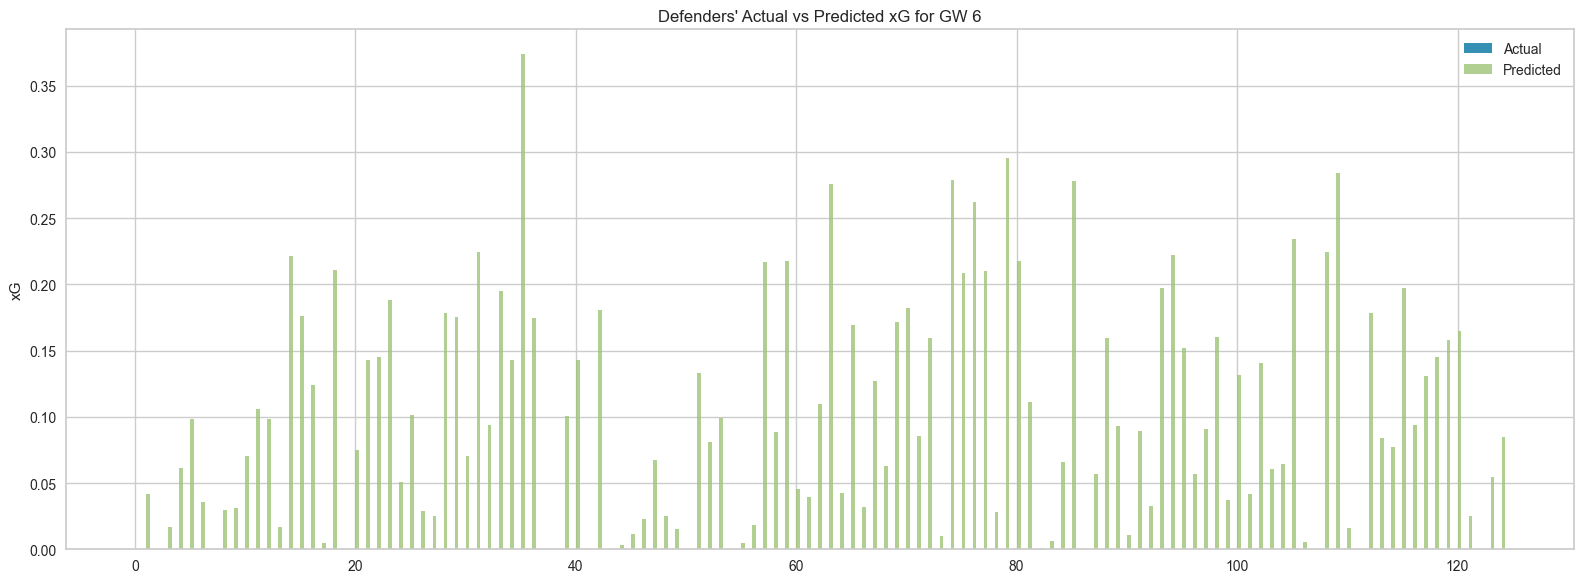

Transformation Pipeline and Model Successfully Loaded


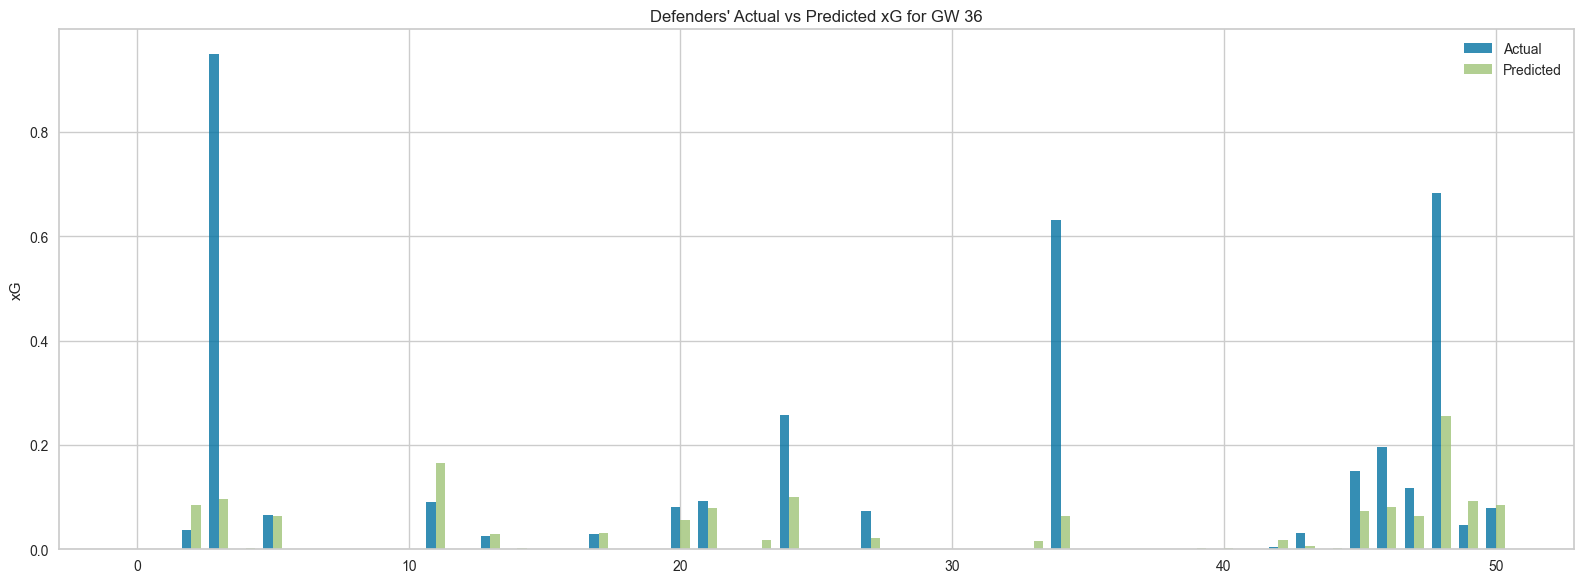

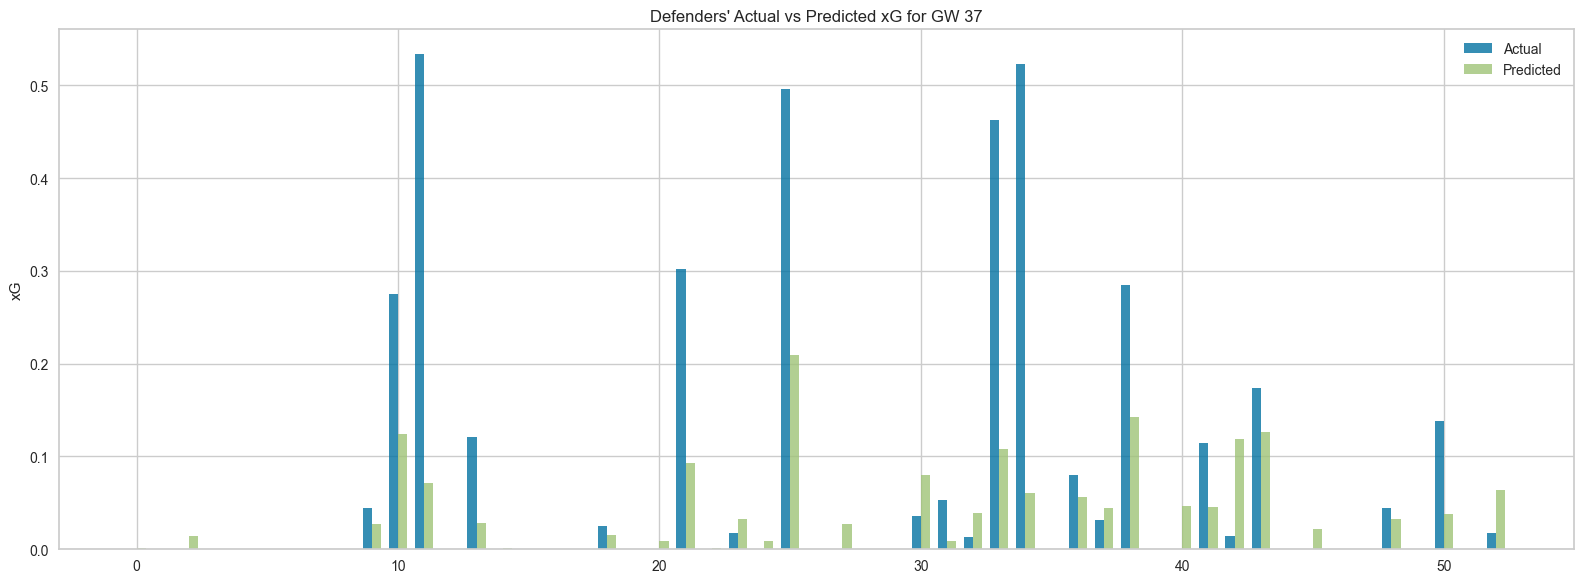

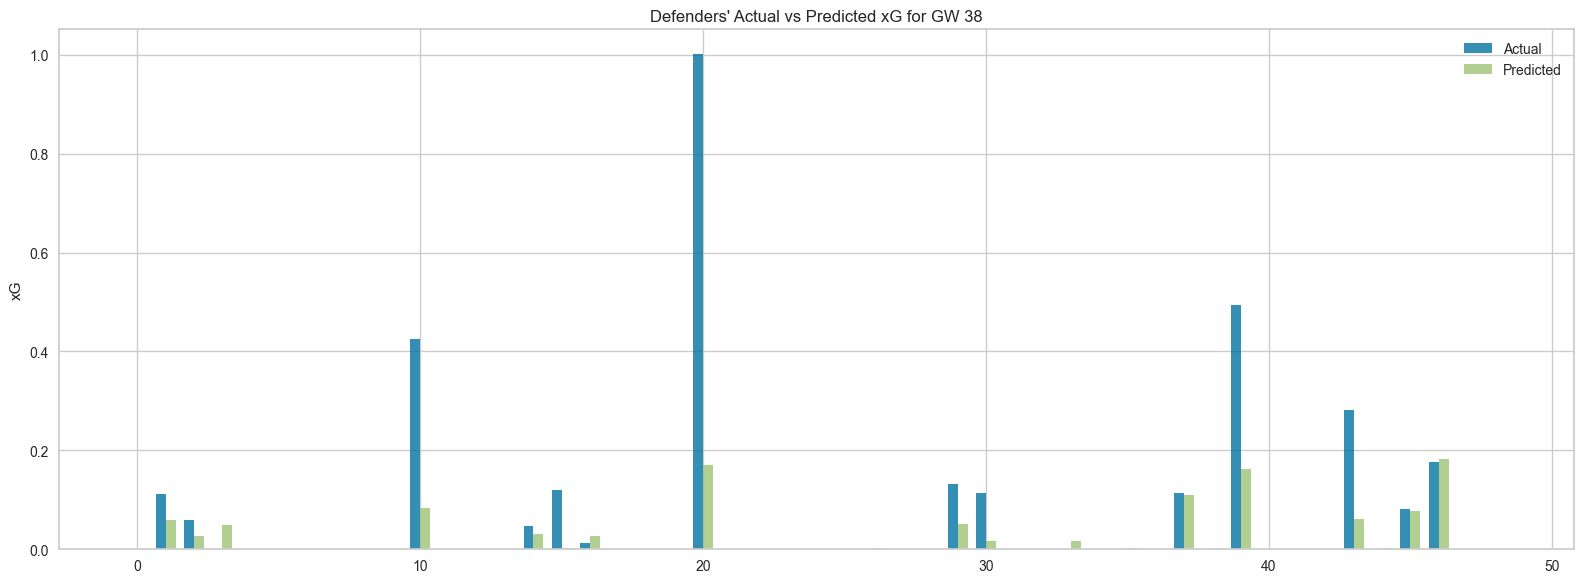

Transformation Pipeline and Model Successfully Loaded


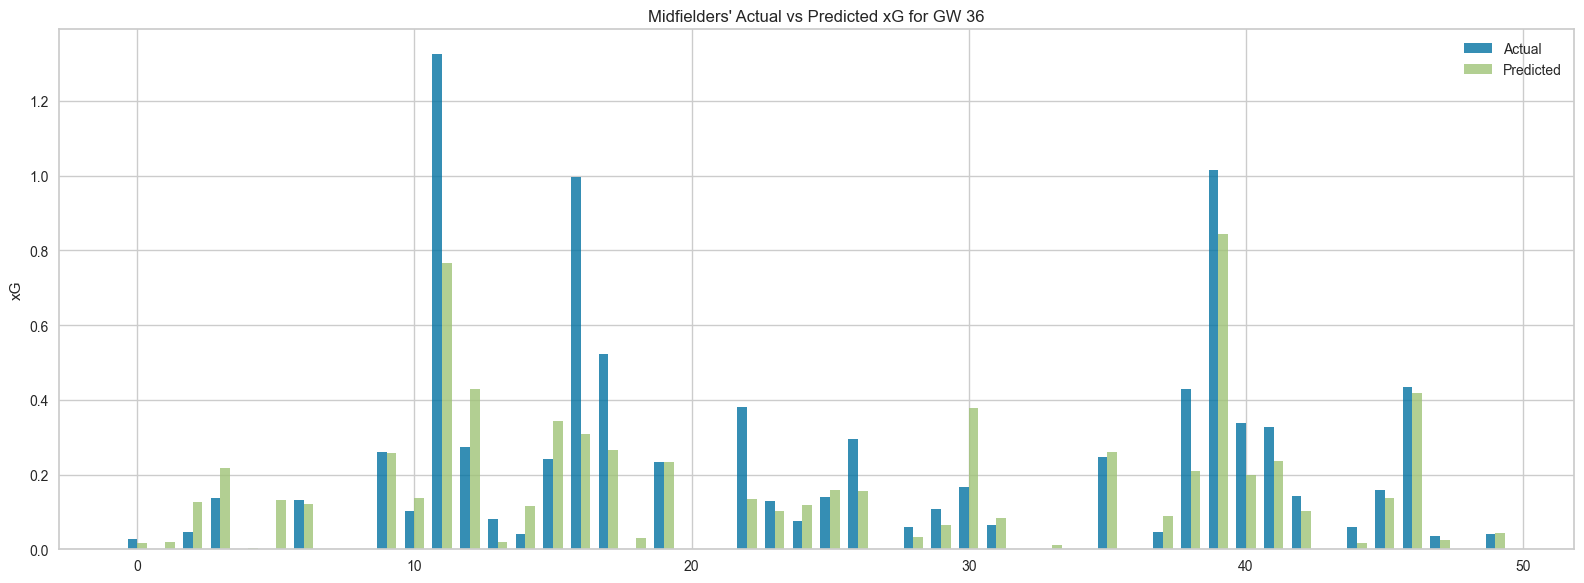

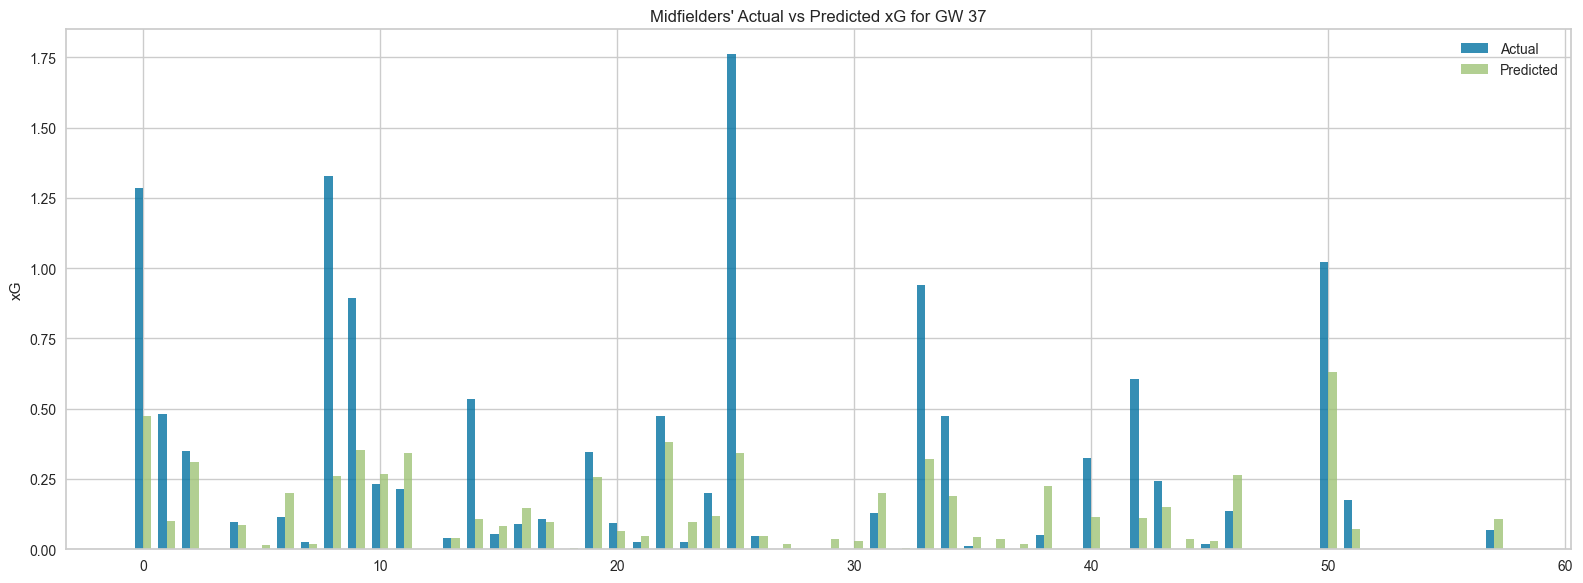

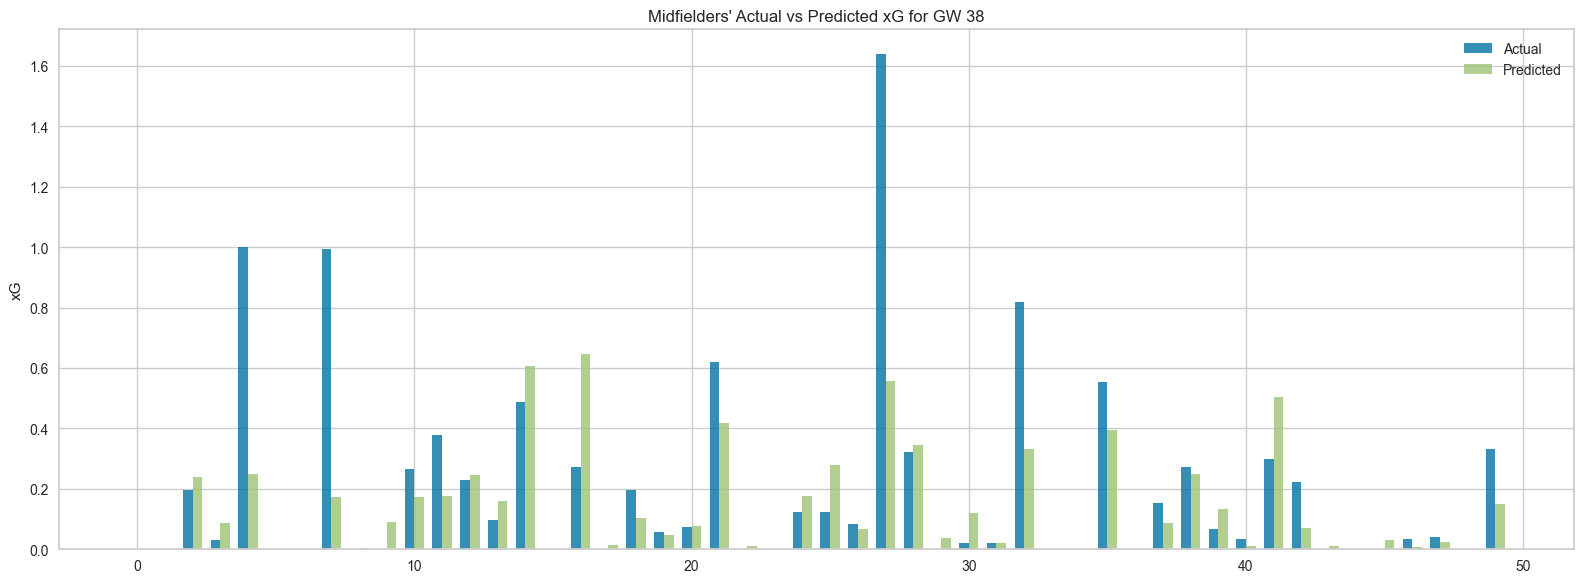

Transformation Pipeline and Model Successfully Loaded


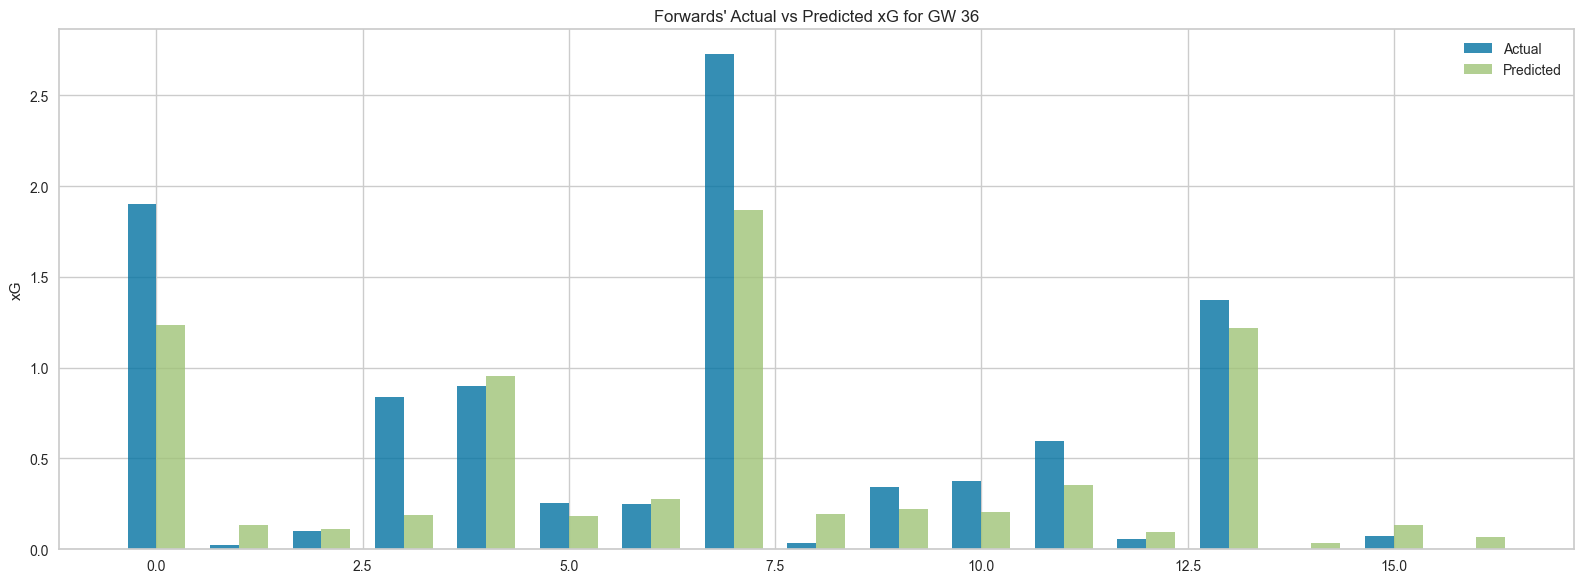

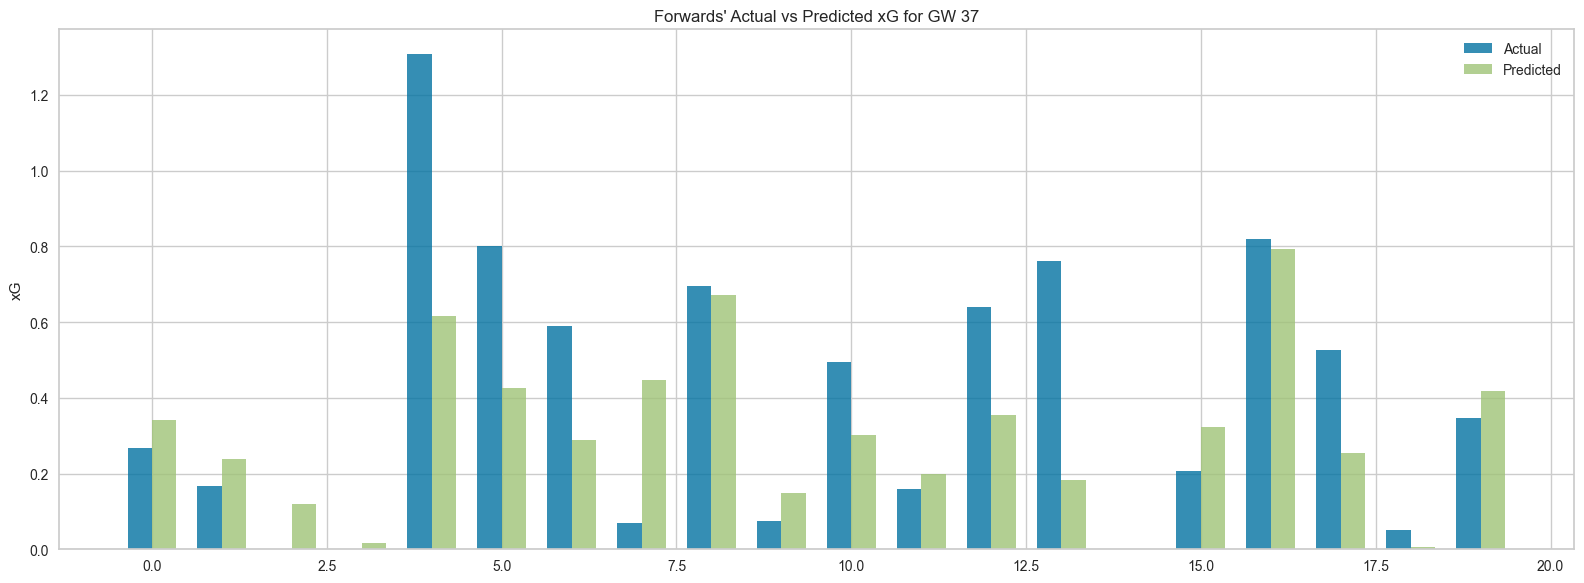

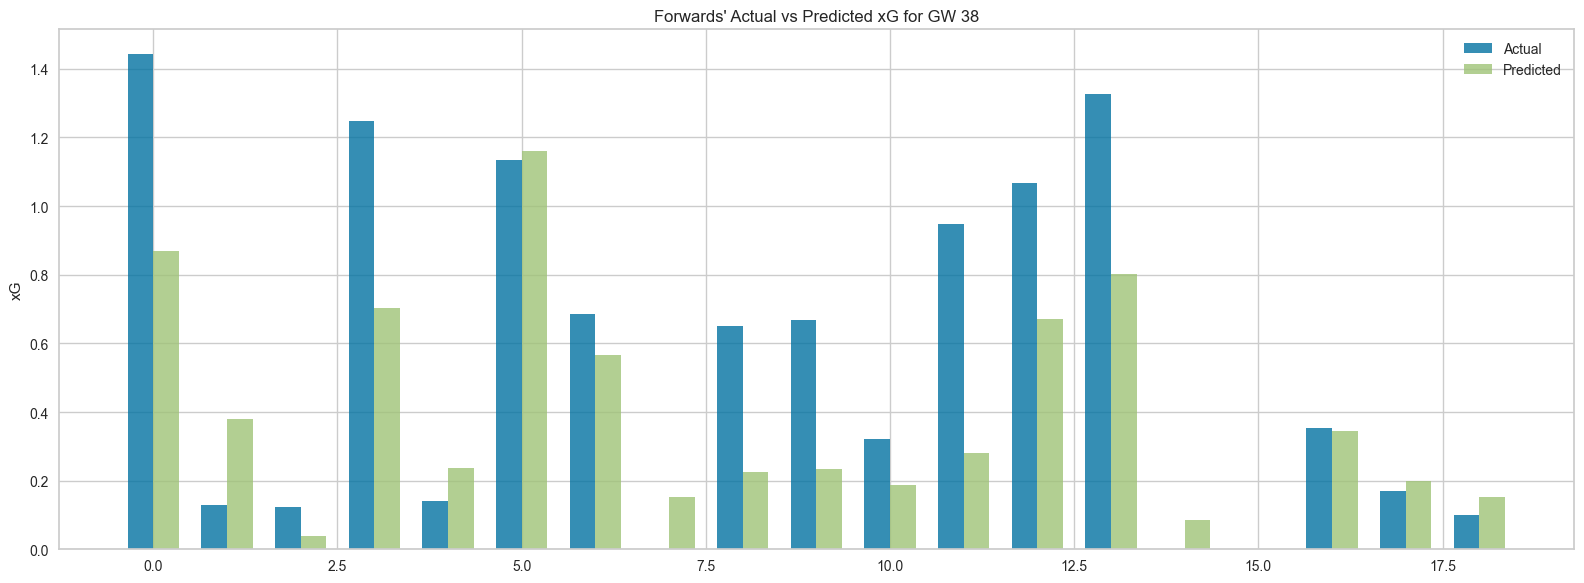

Transformation Pipeline and Model Successfully Loaded


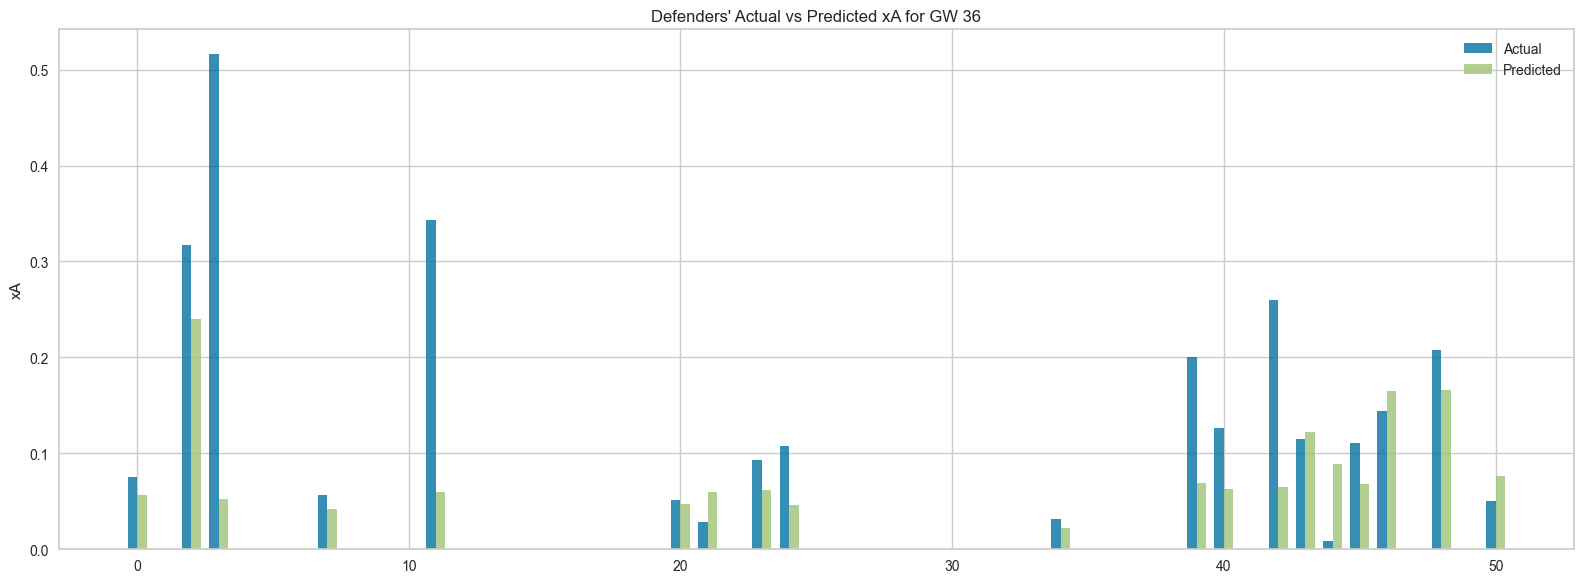

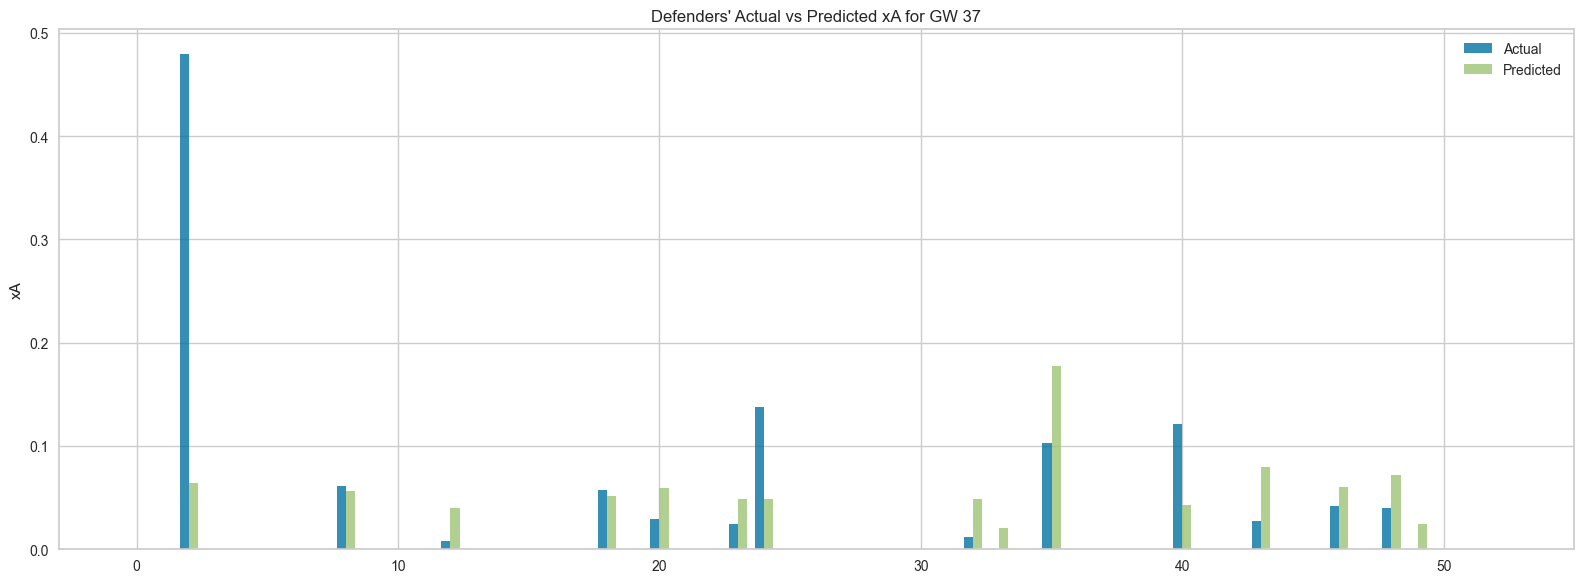

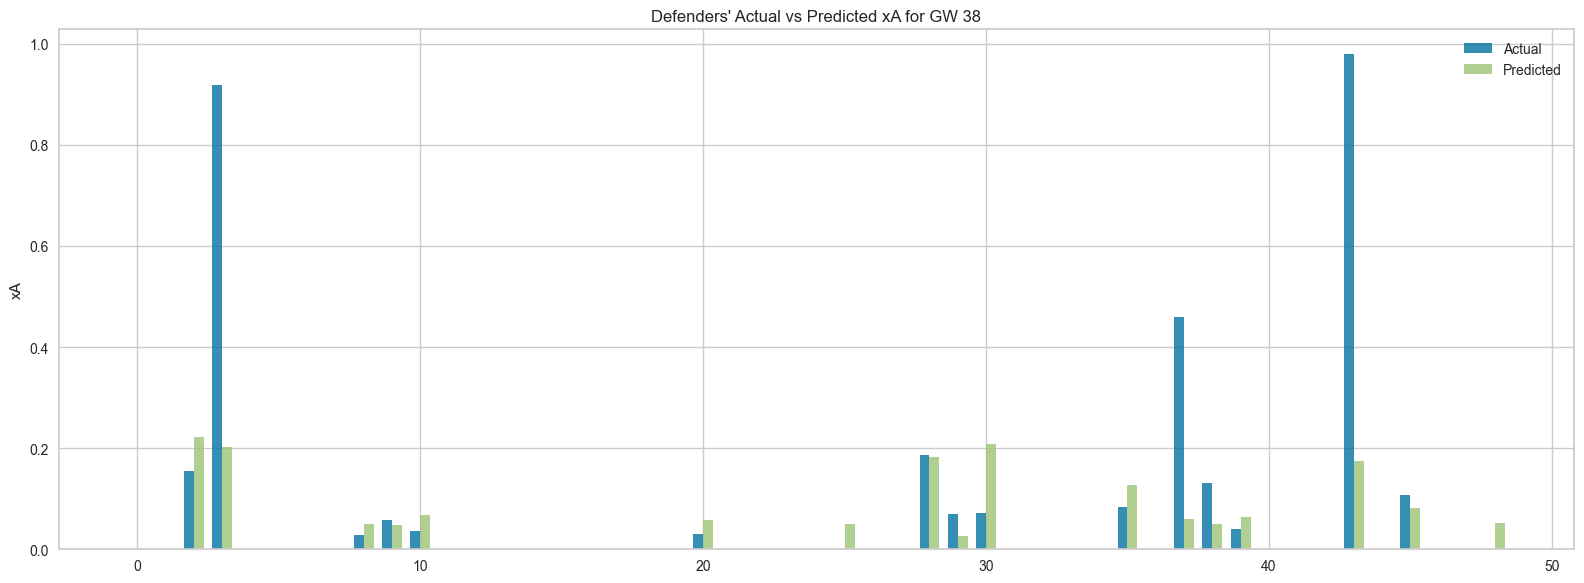

Transformation Pipeline and Model Successfully Loaded


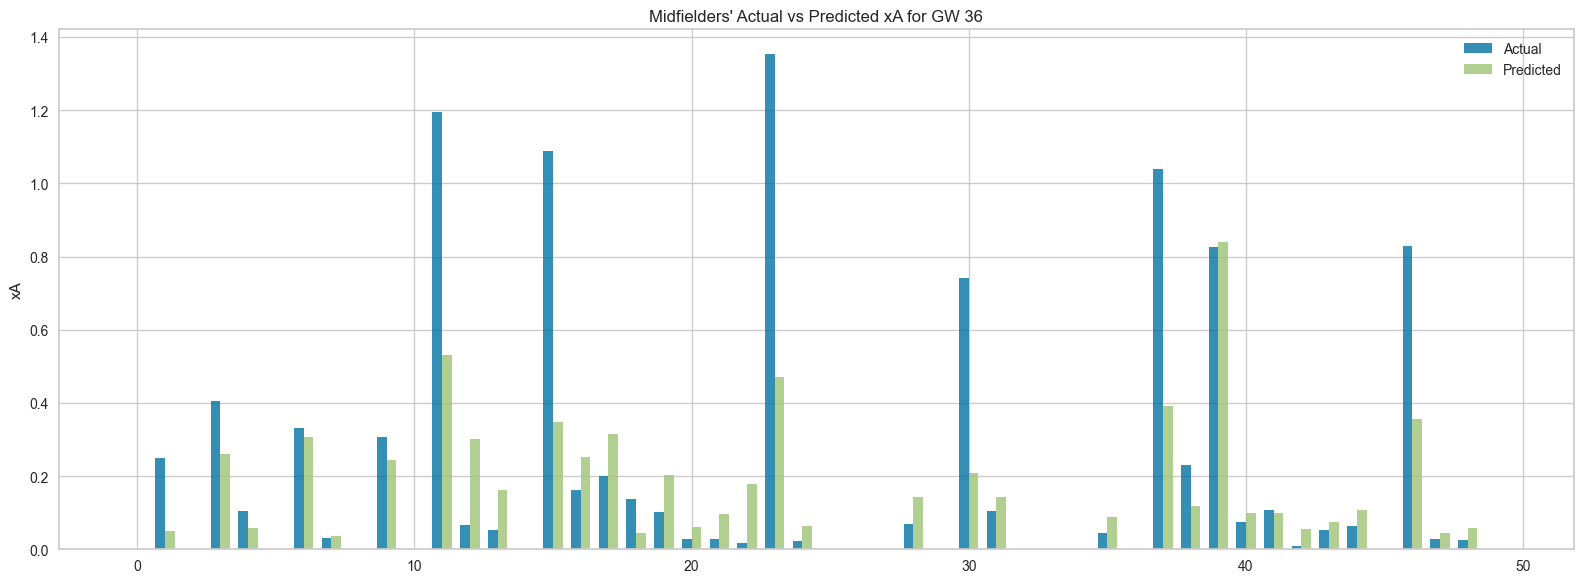

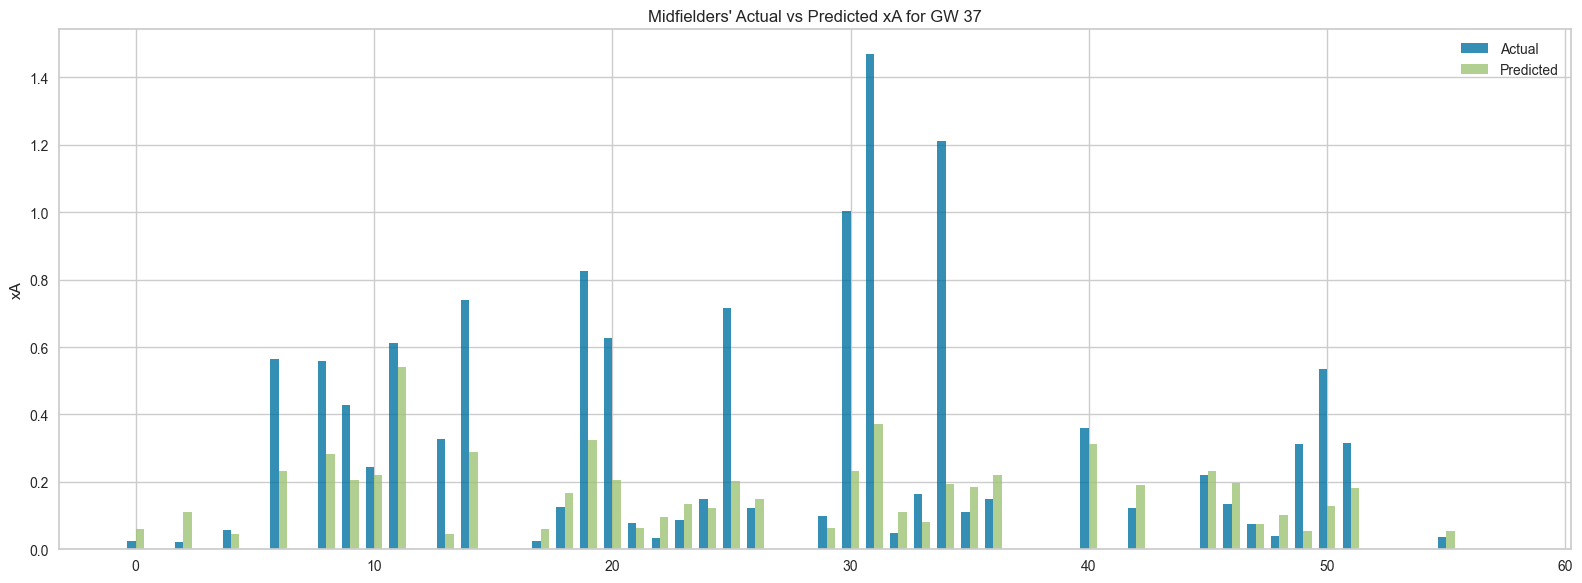

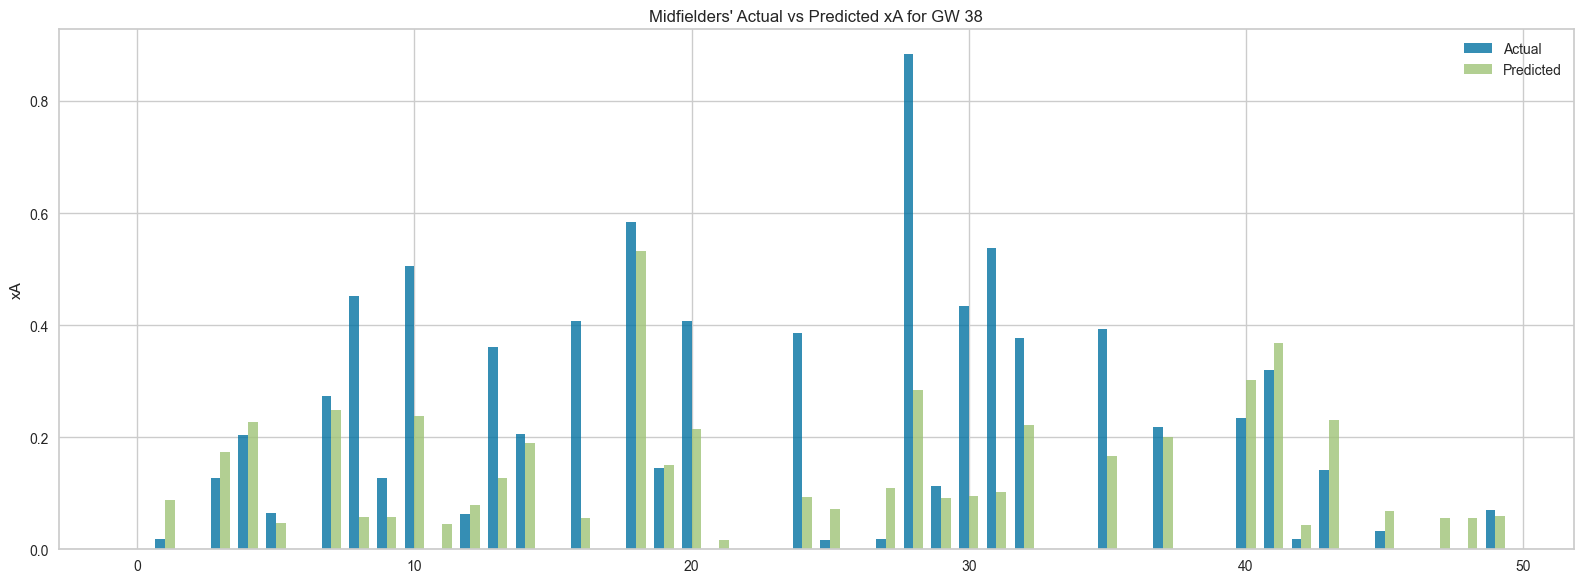

Transformation Pipeline and Model Successfully Loaded


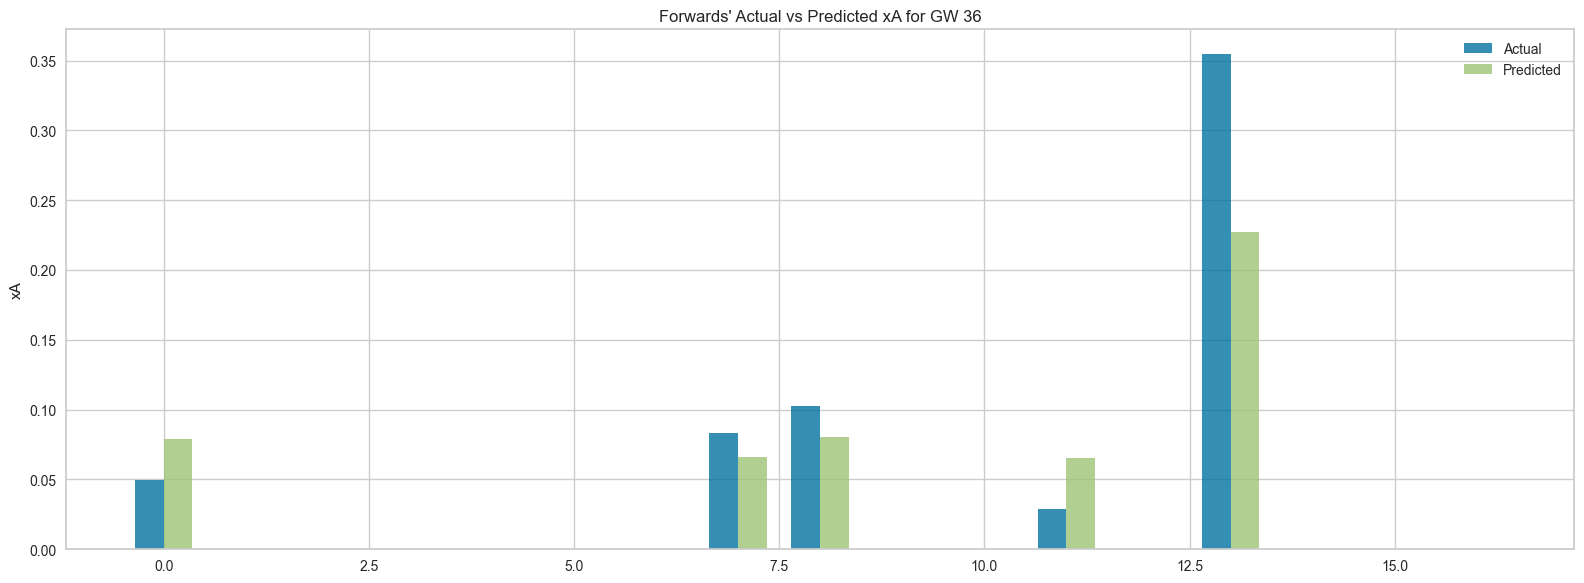

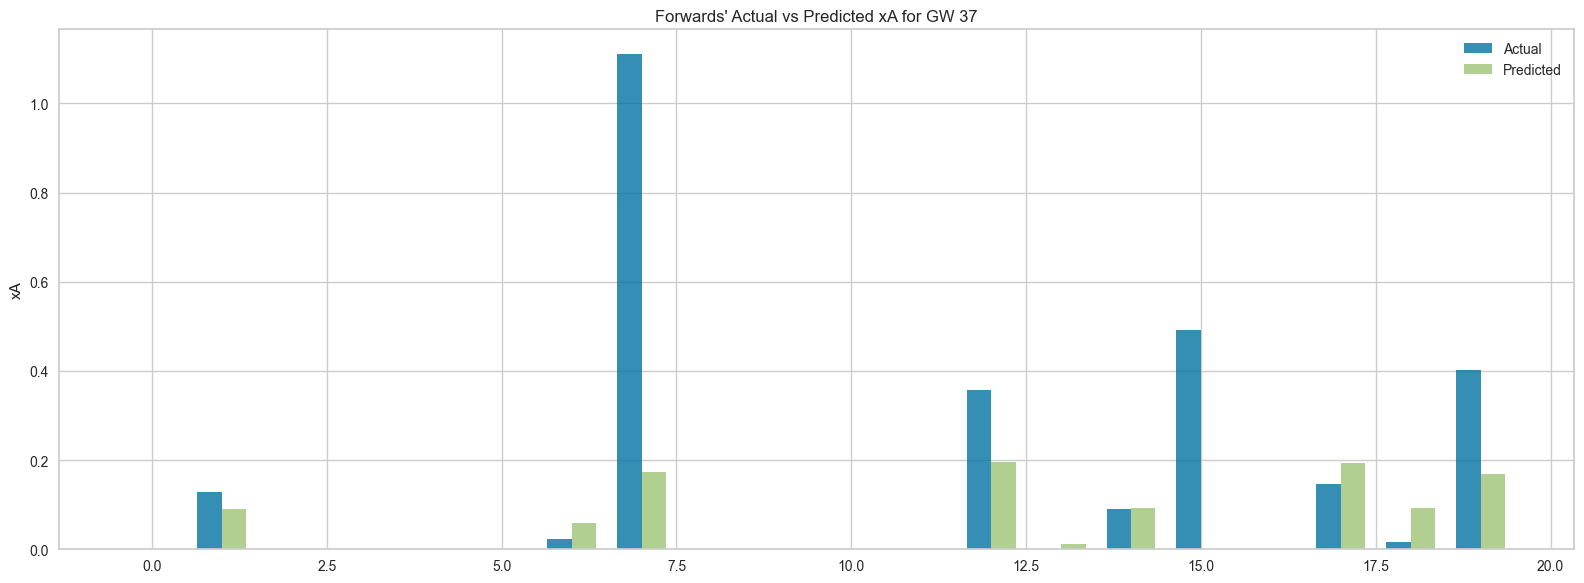

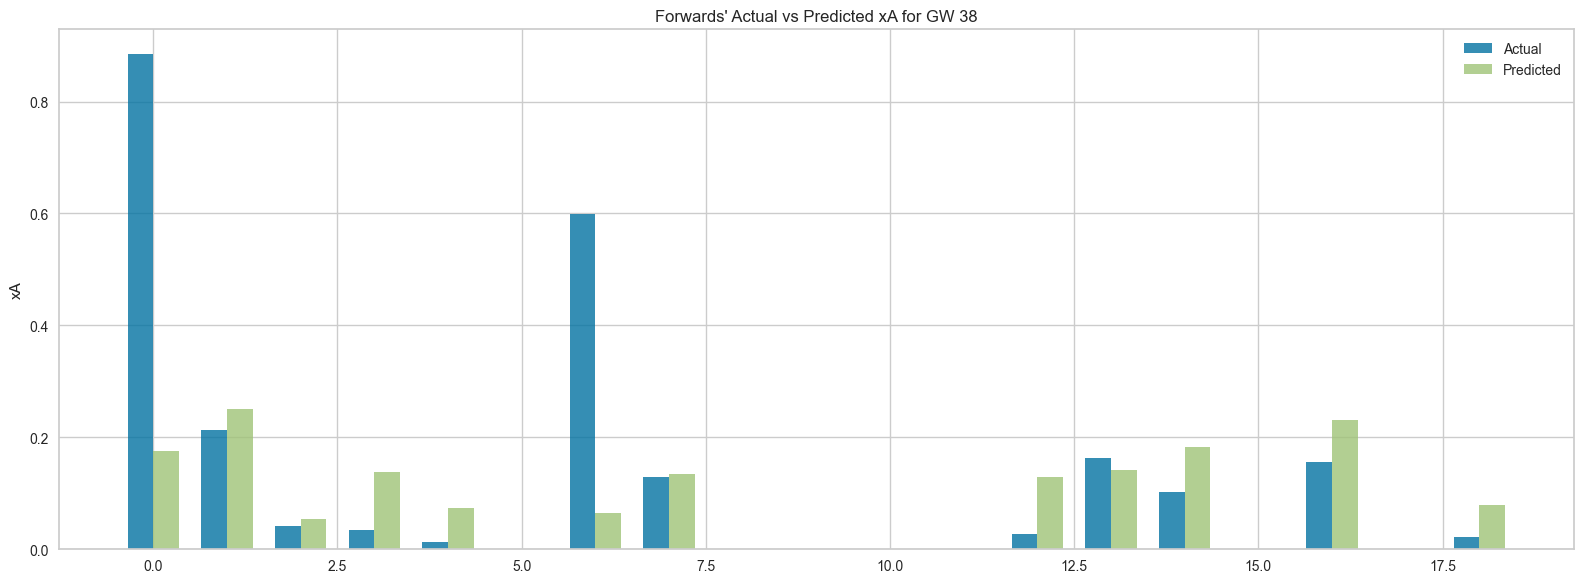

Transformation Pipeline and Model Successfully Loaded


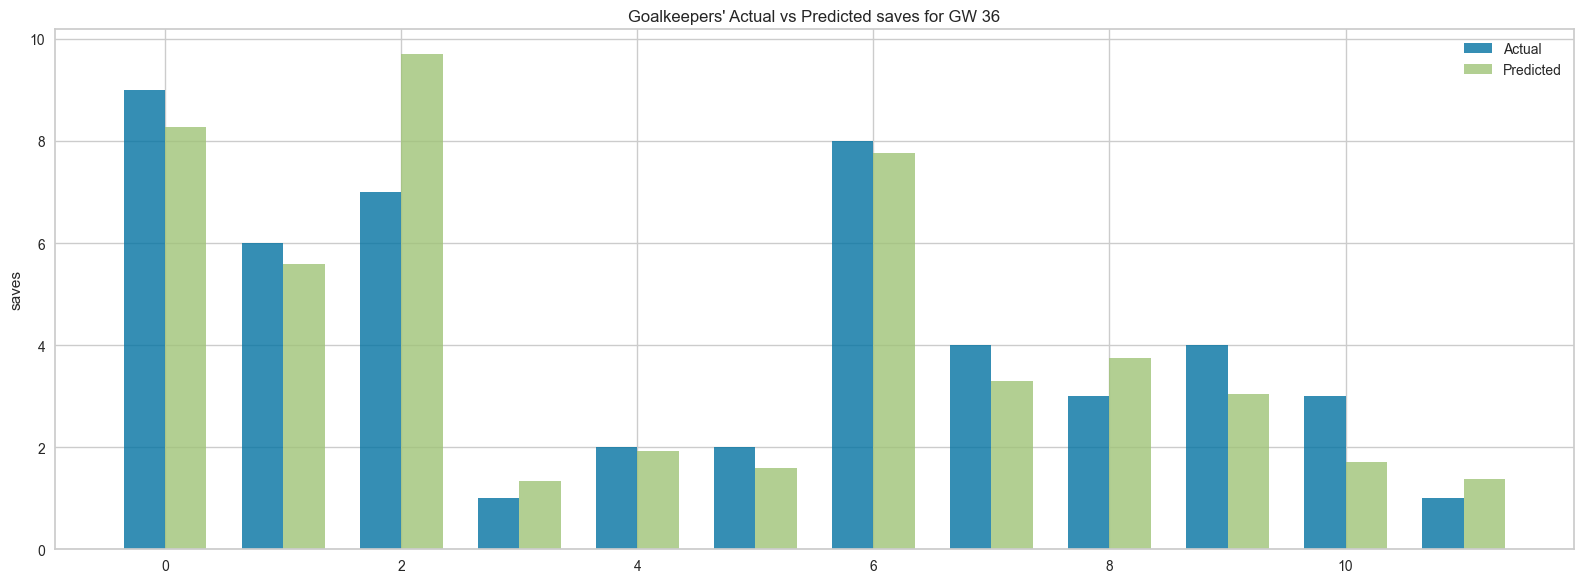

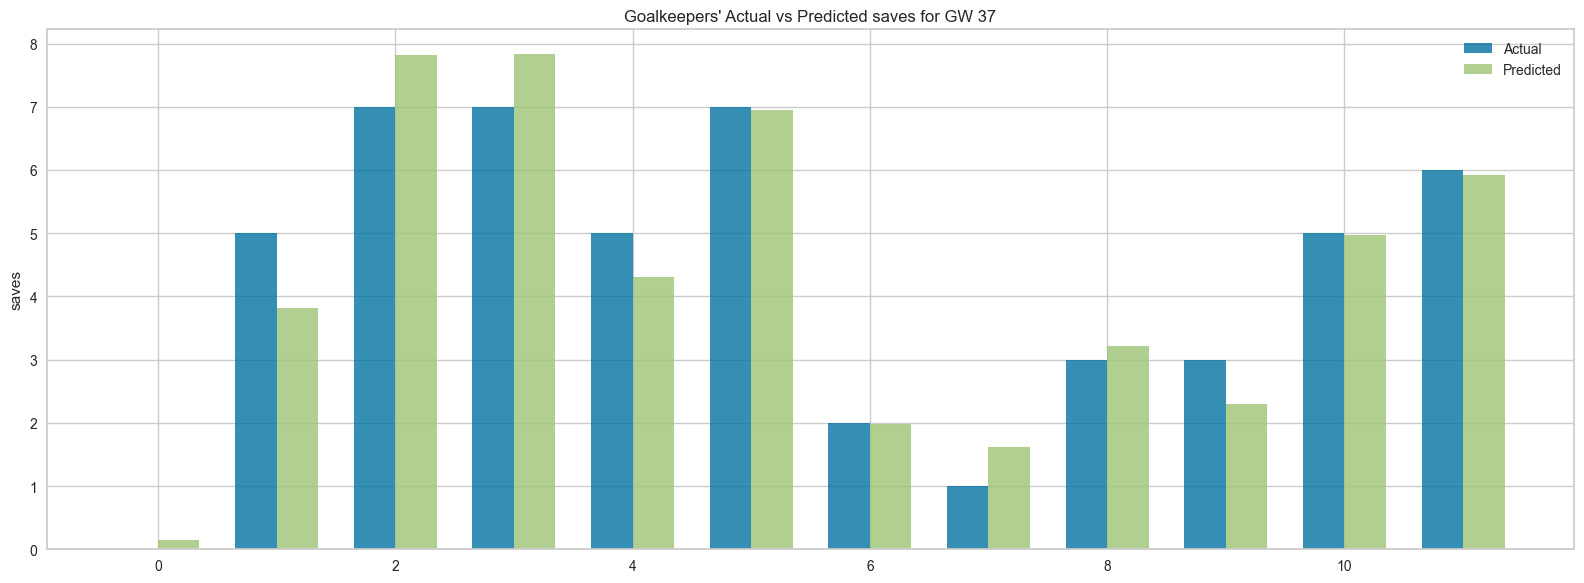

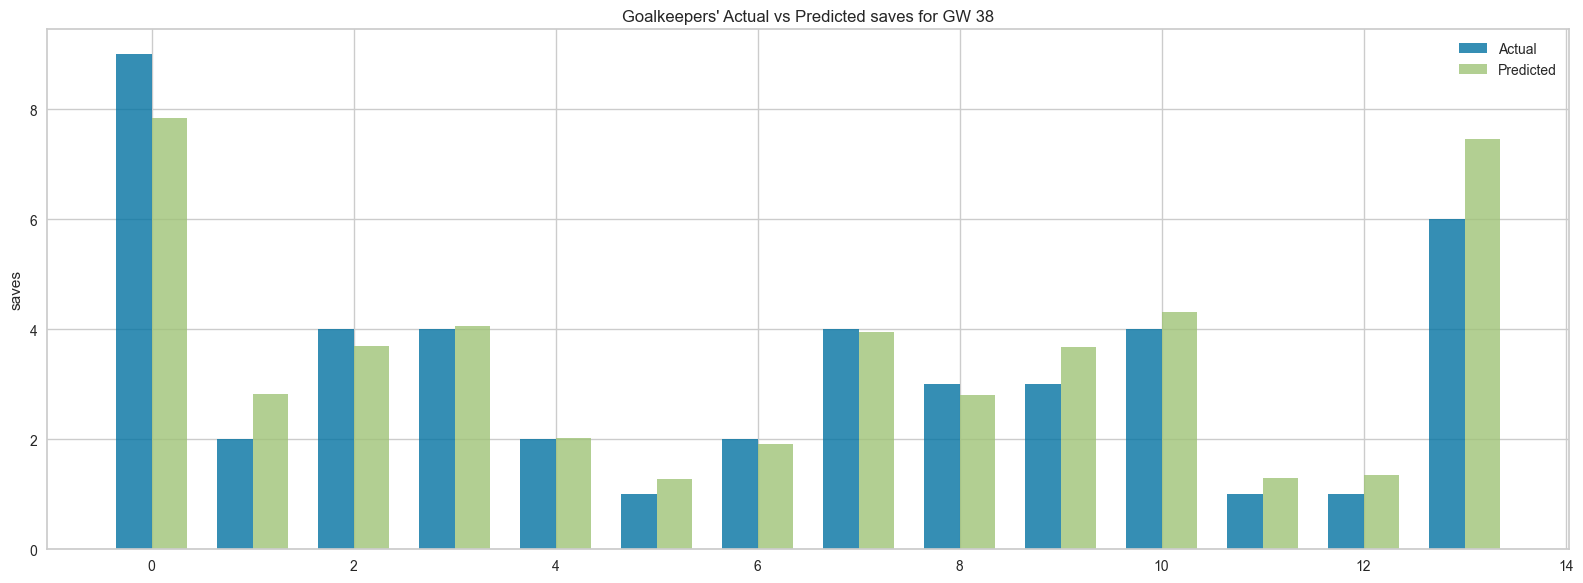

(63, 176)
Transformation Pipeline and Model Successfully Loaded


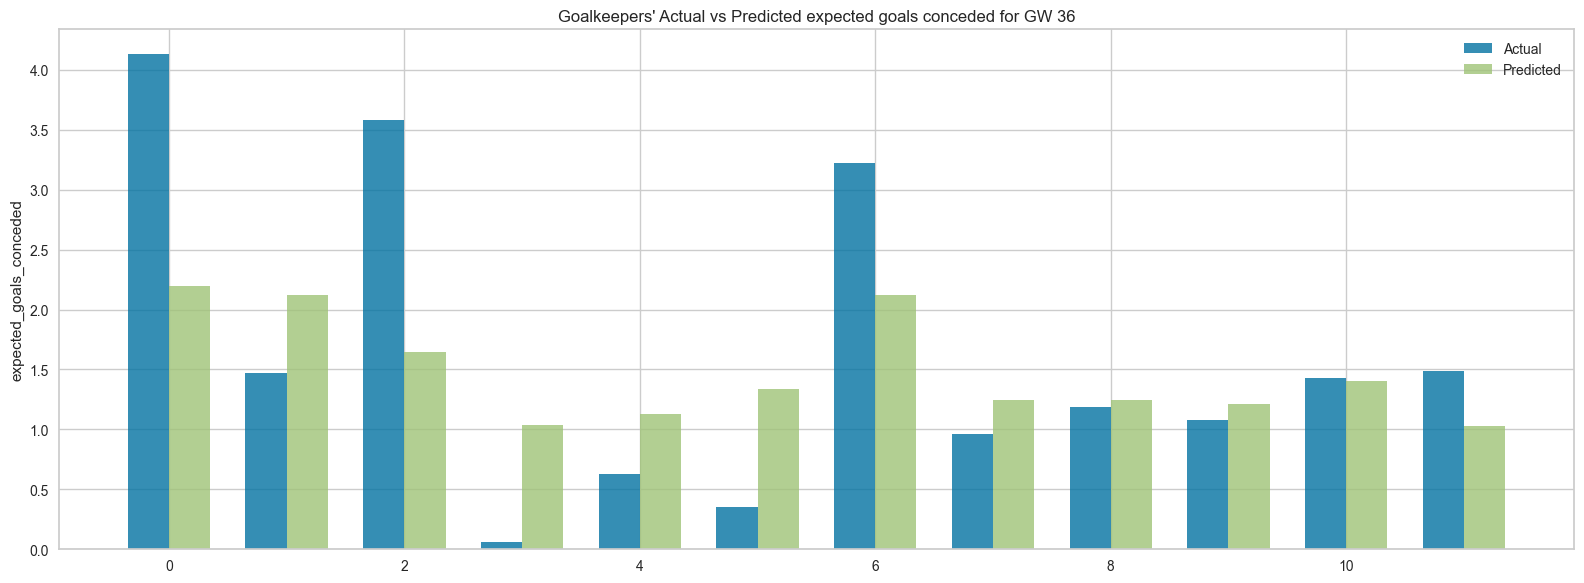

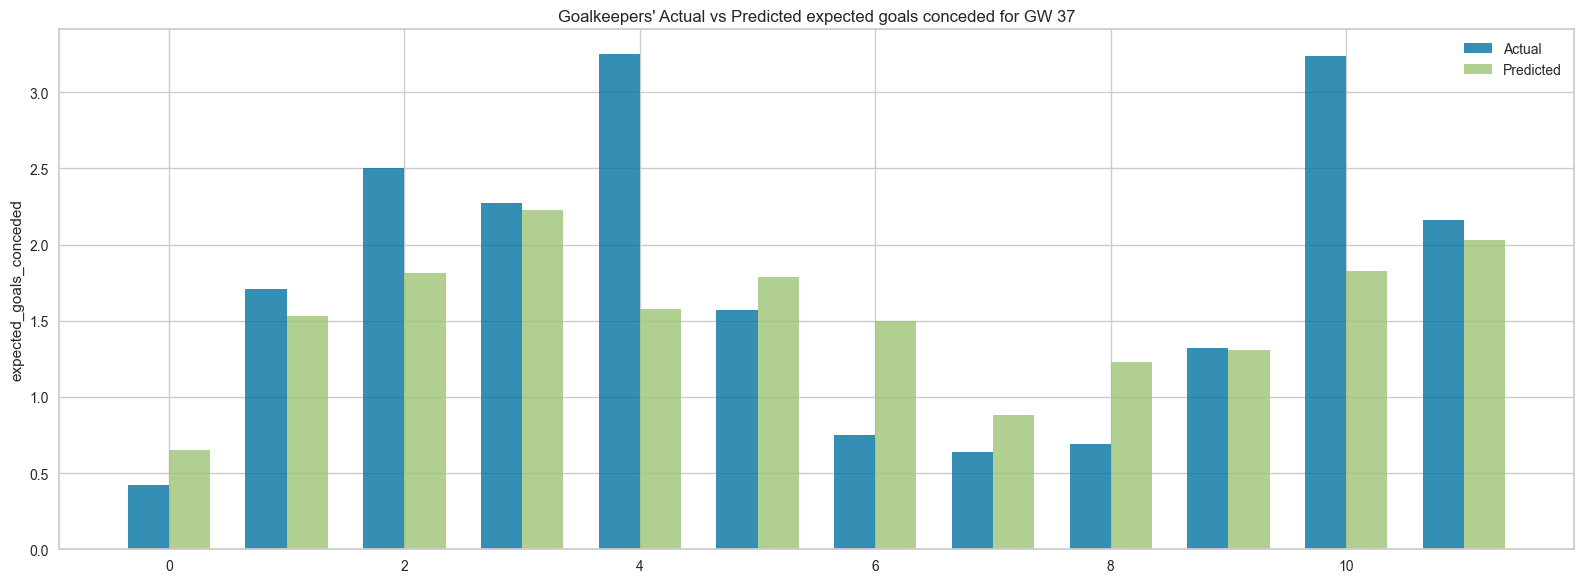

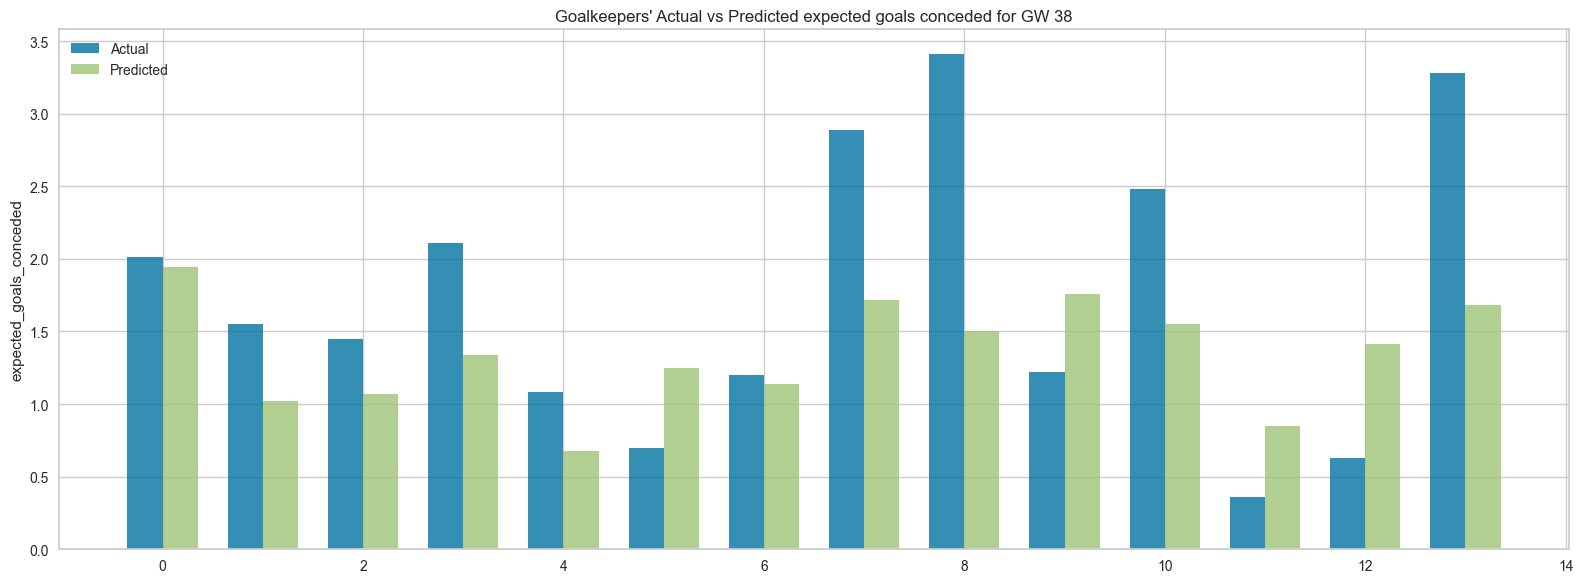

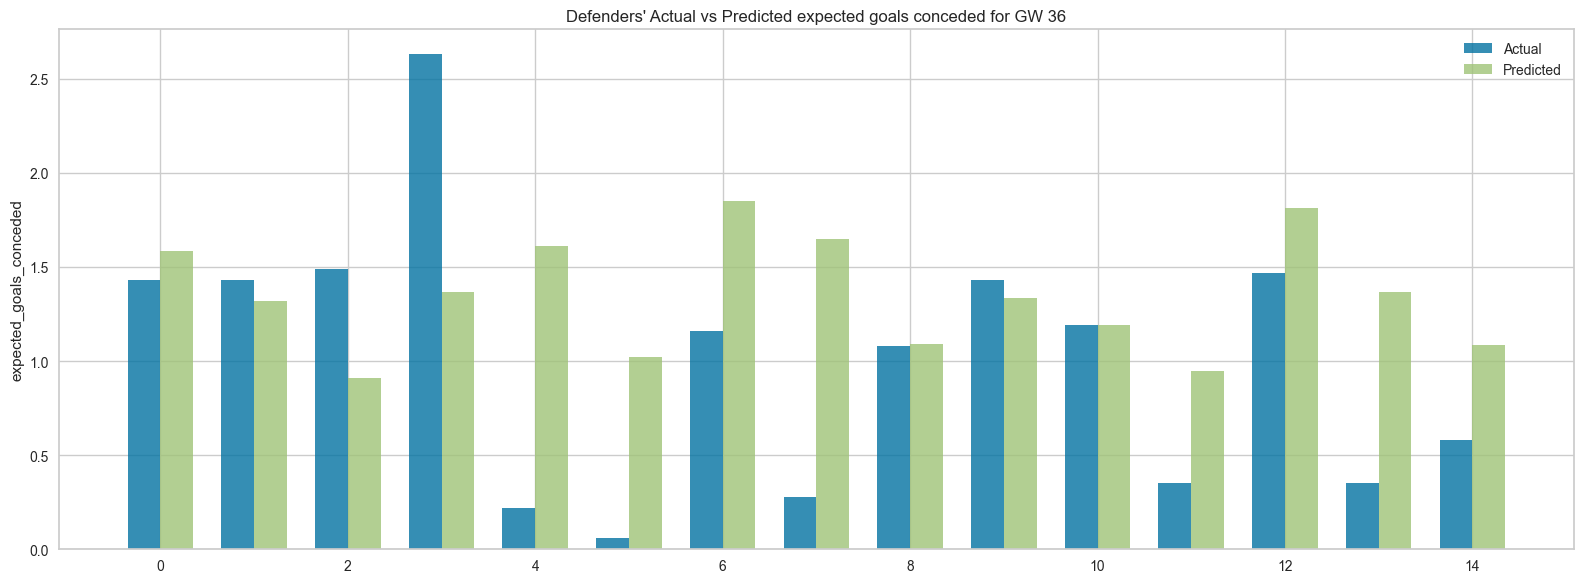

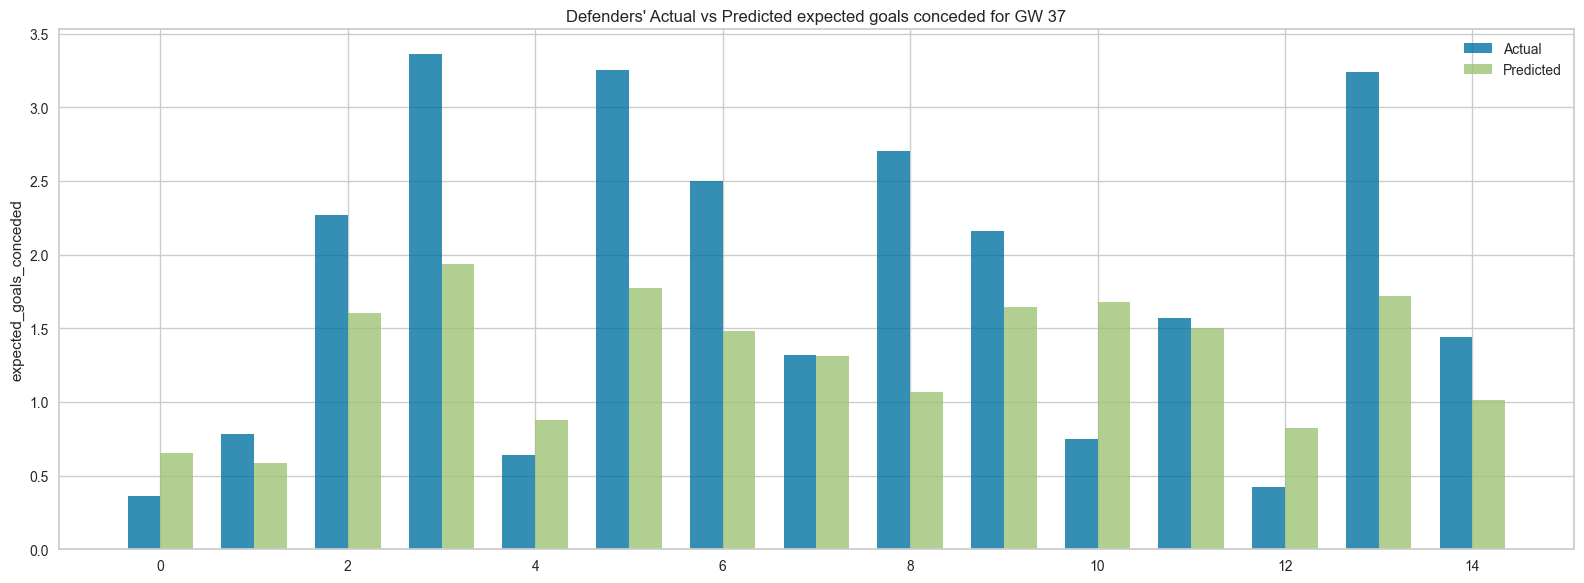

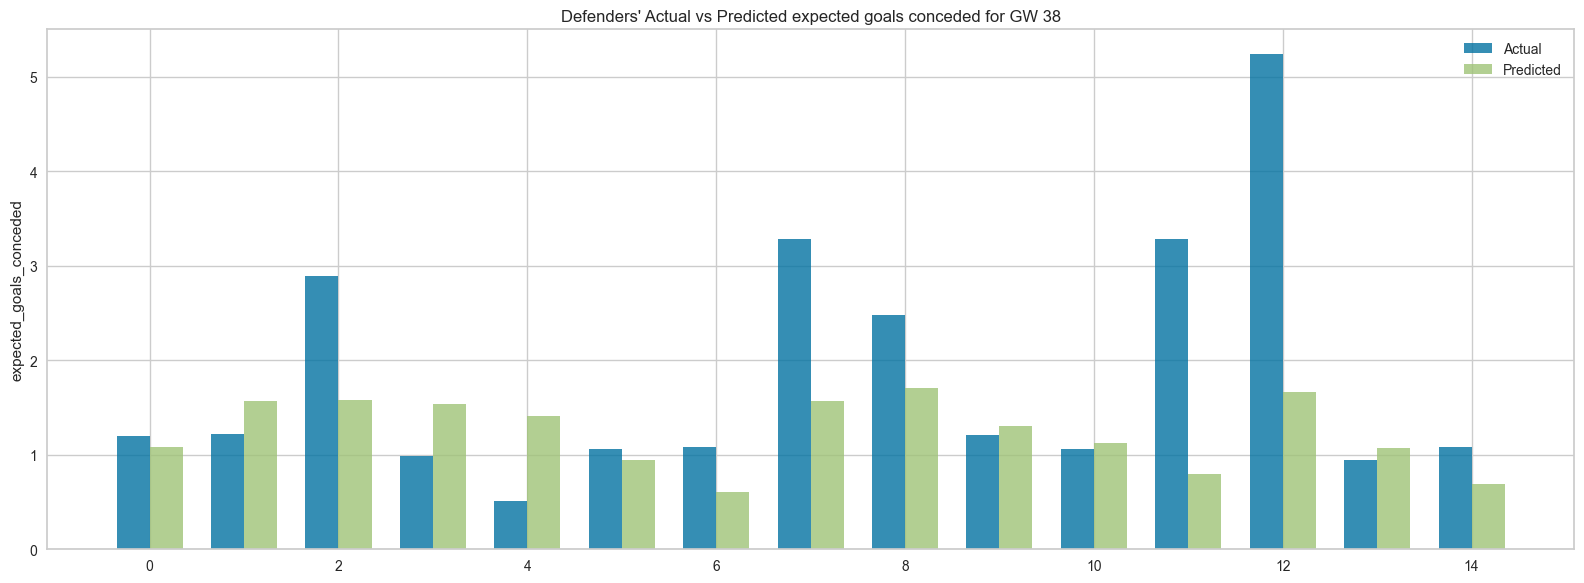

Transformation Pipeline and Model Successfully Loaded


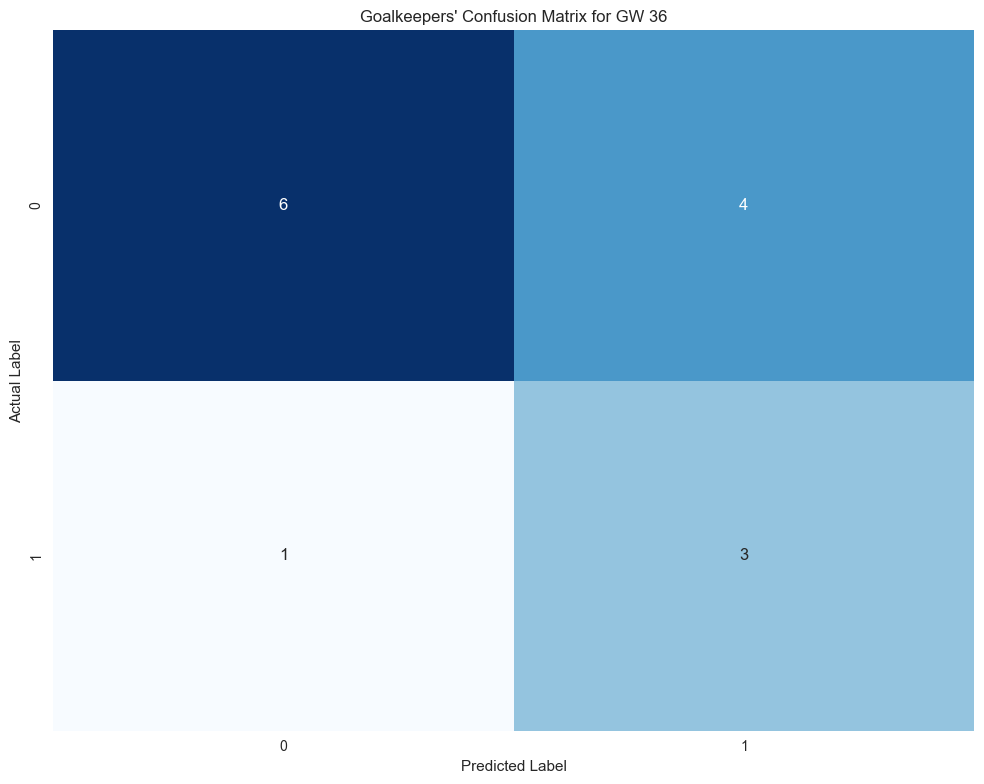

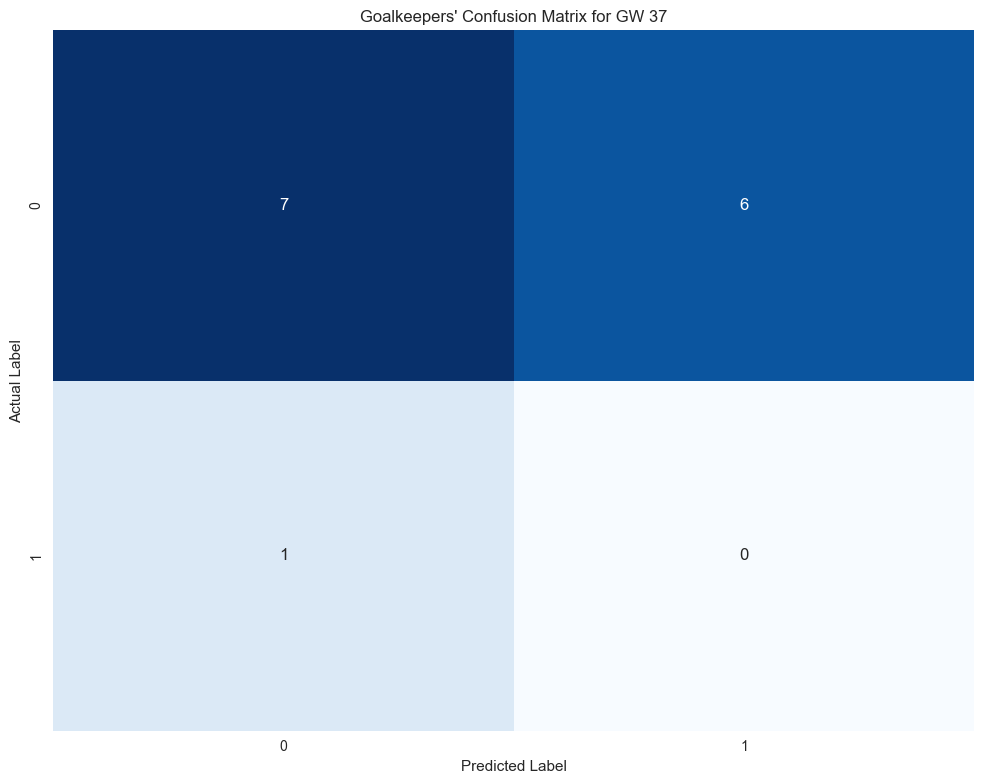

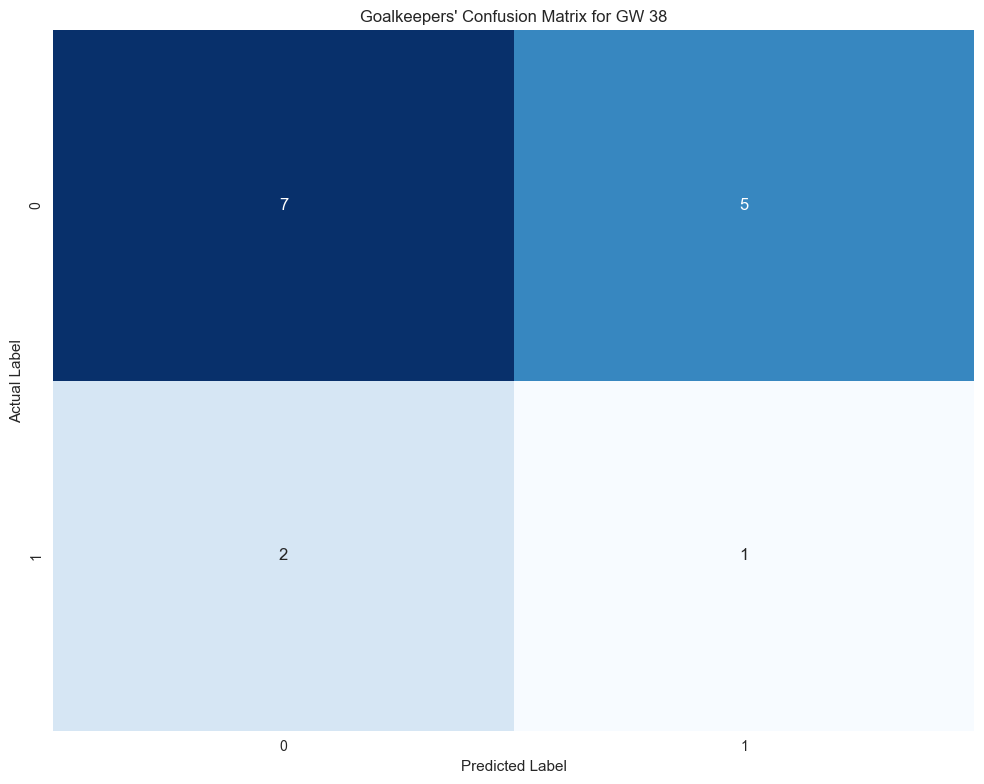

Transformation Pipeline and Model Successfully Loaded


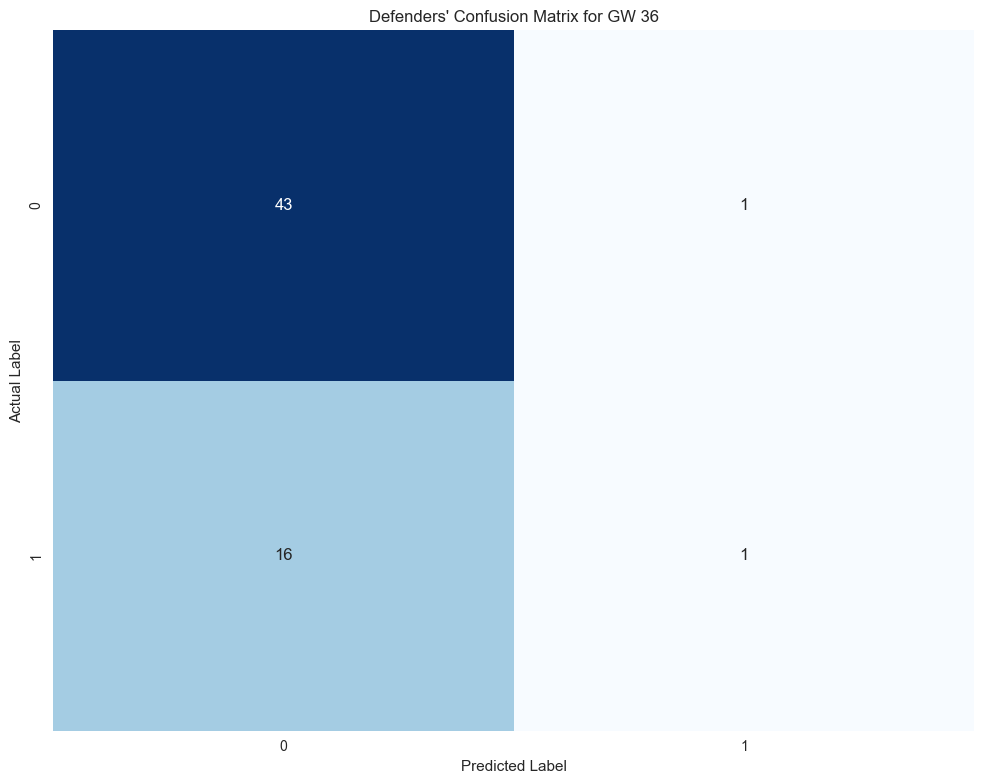

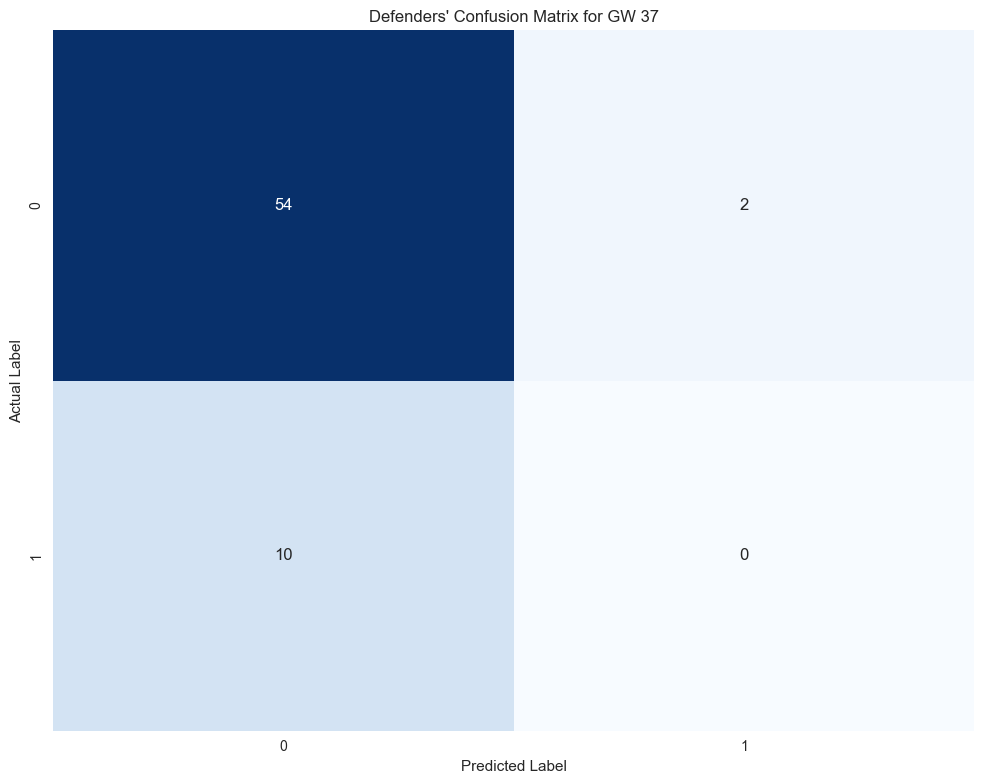

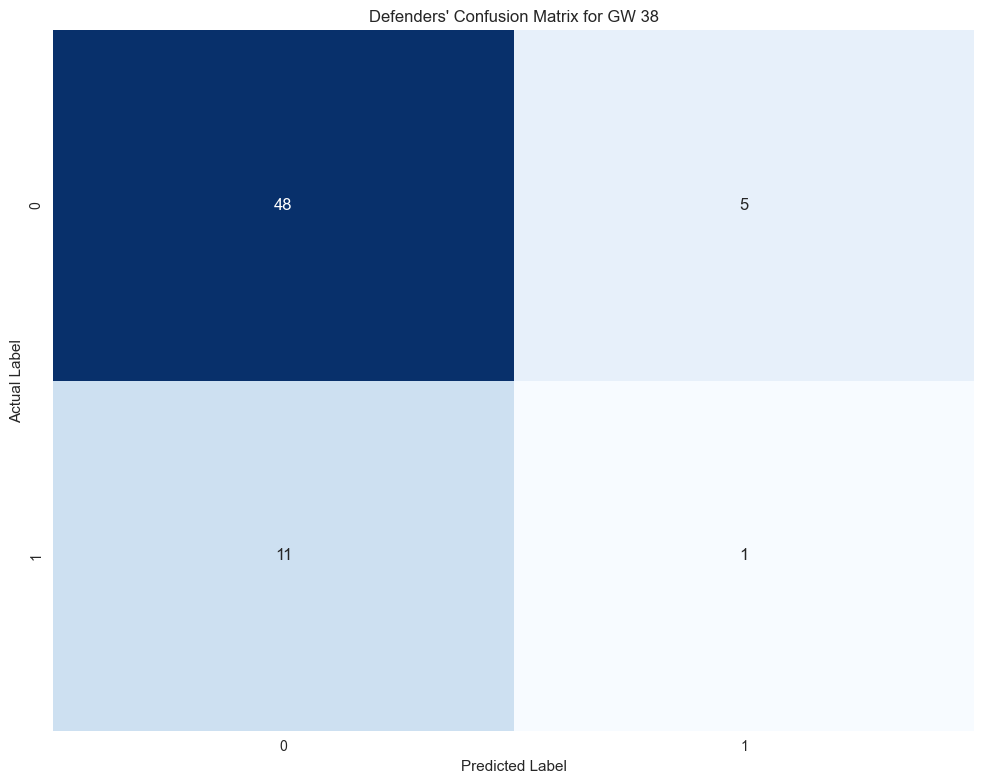

Transformation Pipeline and Model Successfully Loaded


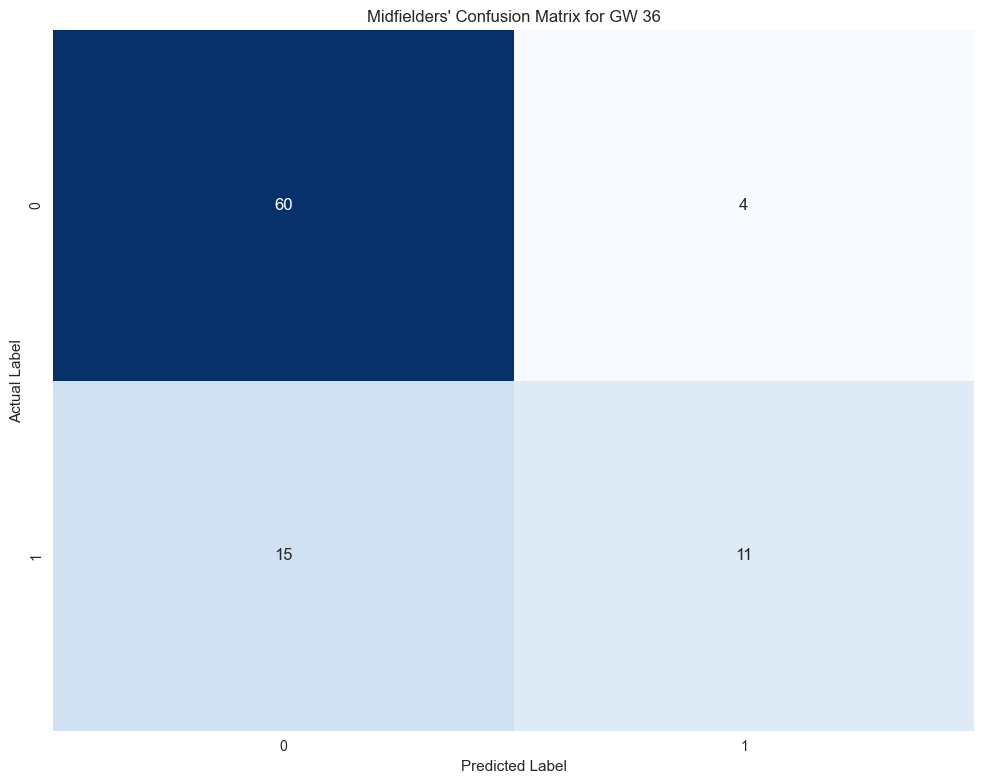

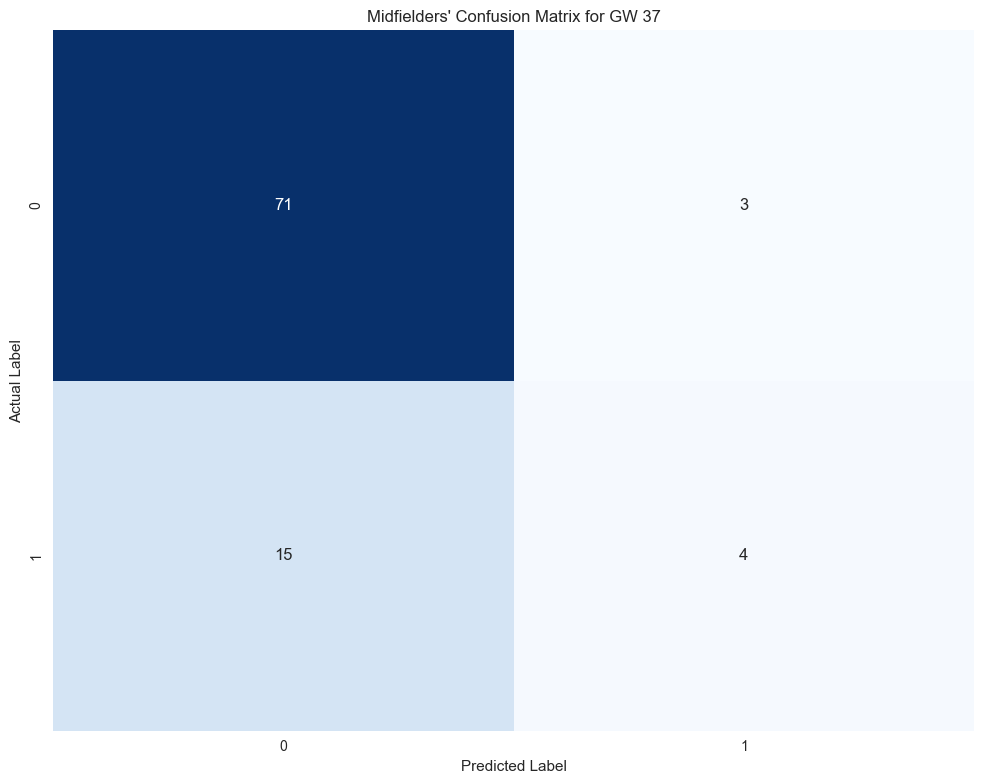

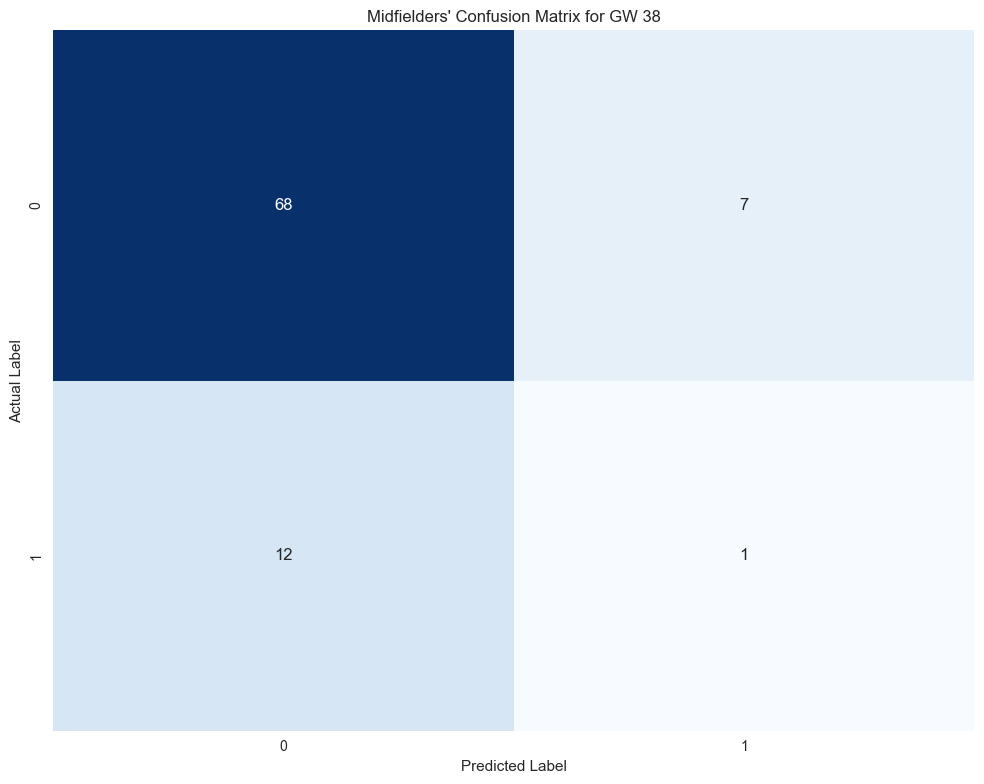

Transformation Pipeline and Model Successfully Loaded


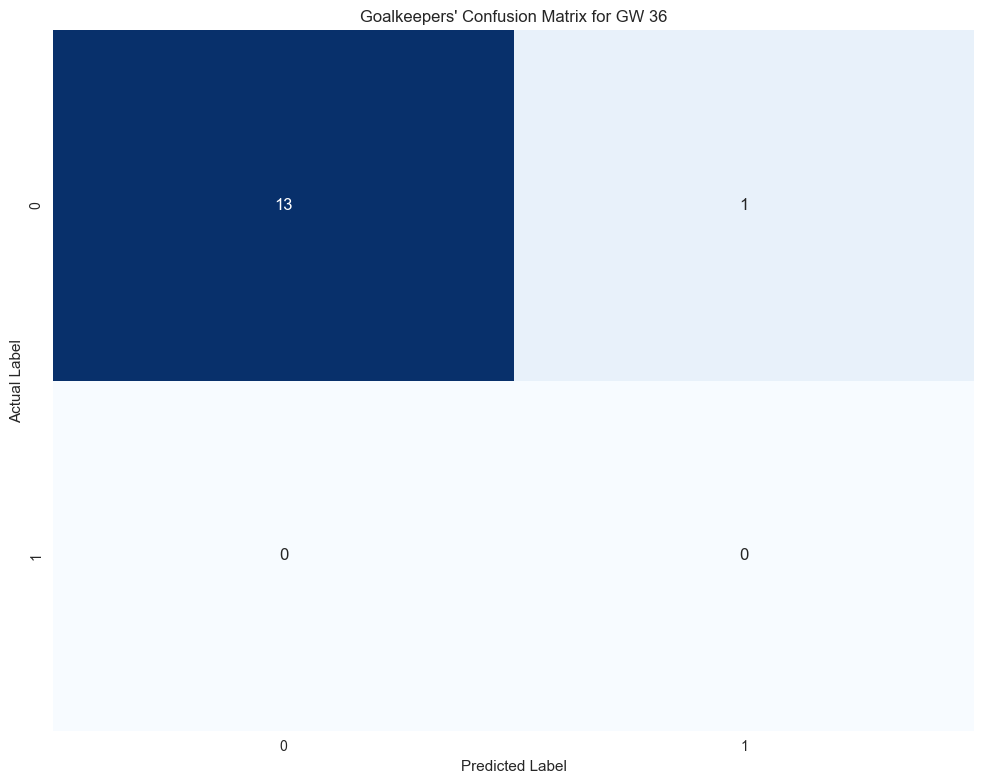

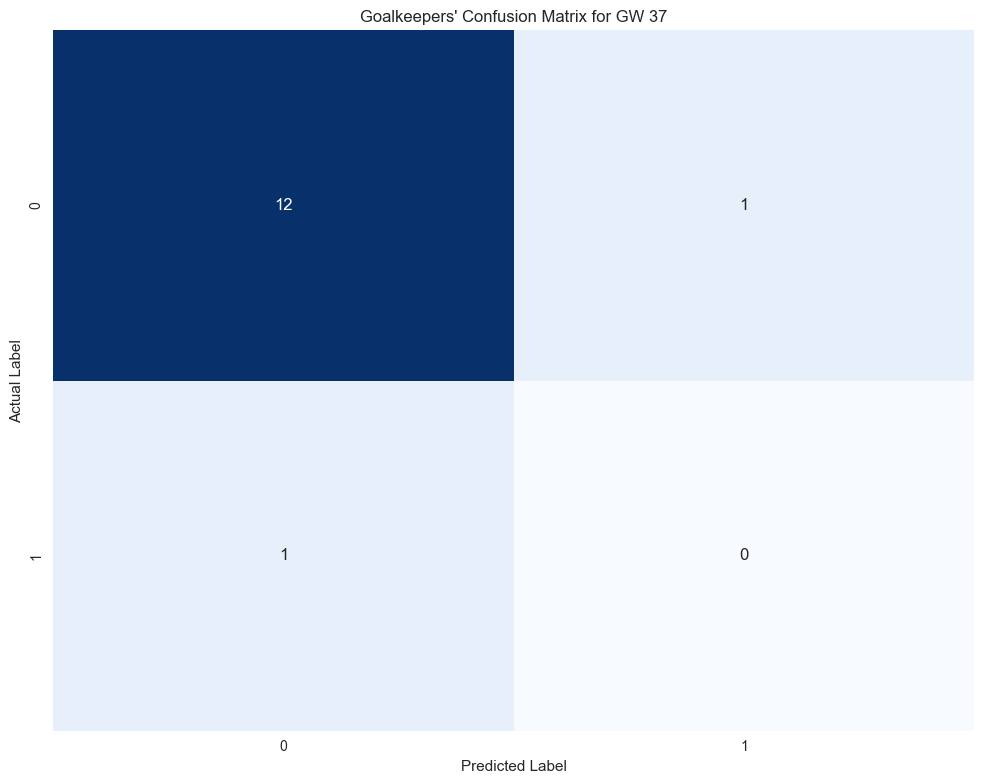

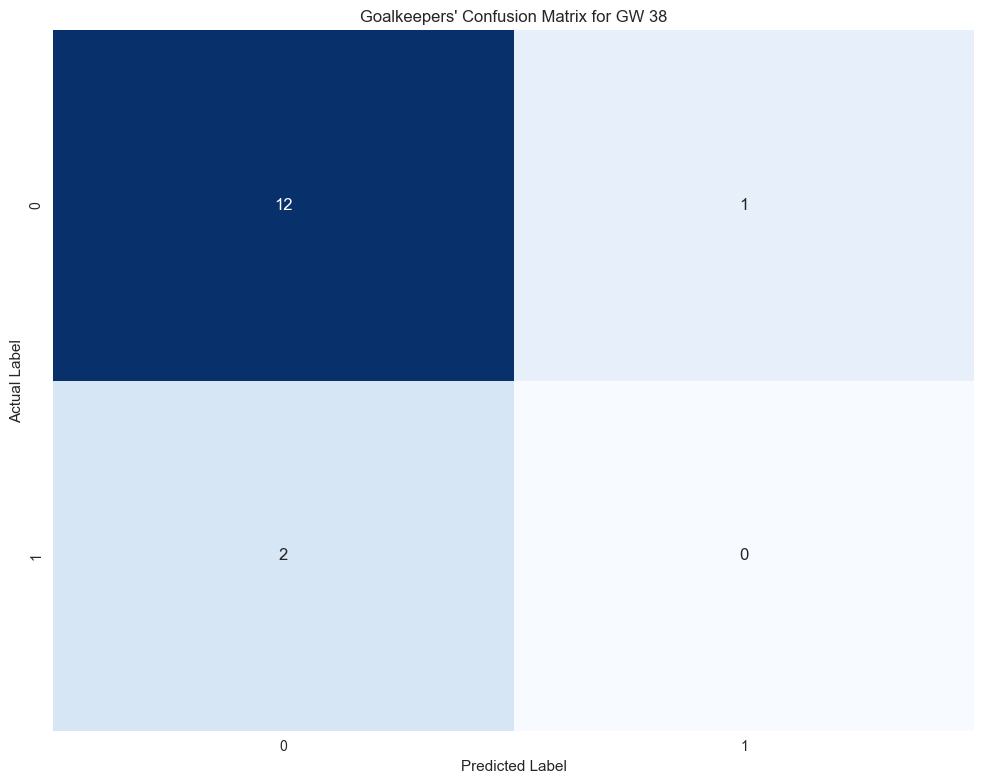

Transformation Pipeline and Model Successfully Loaded


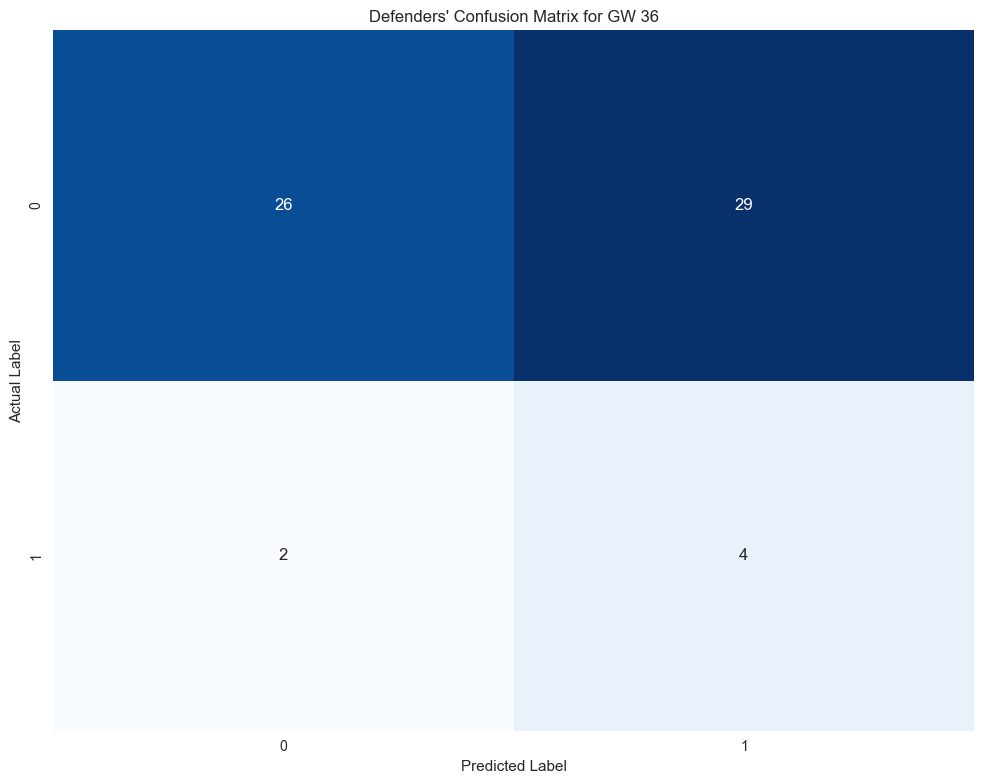

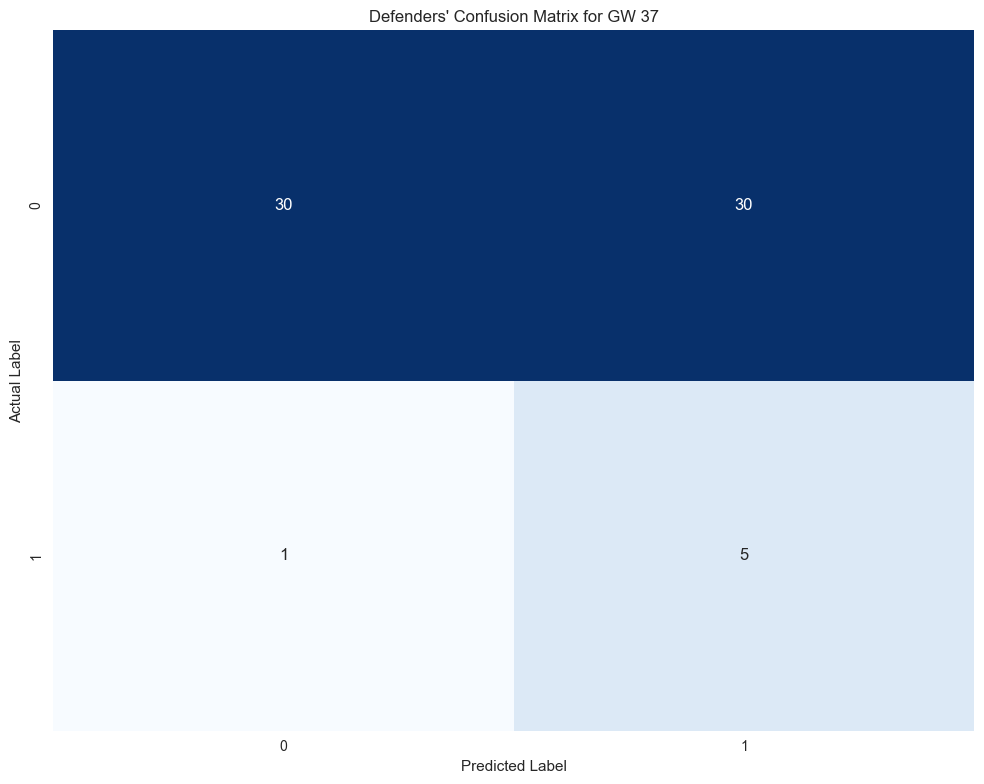

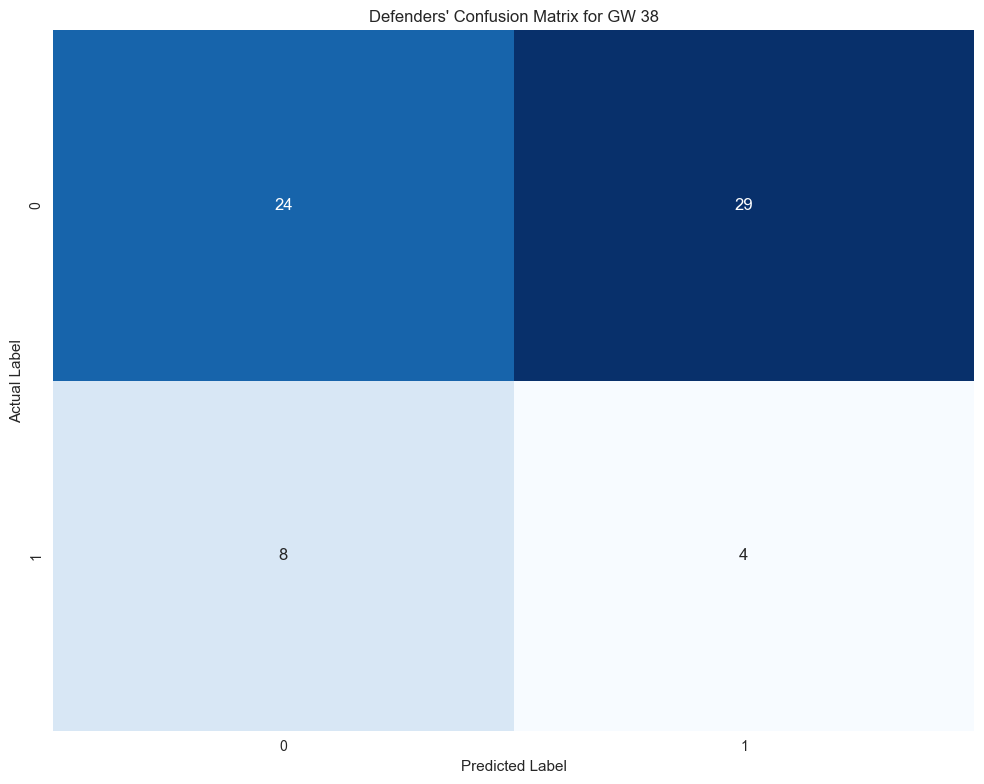

Transformation Pipeline and Model Successfully Loaded


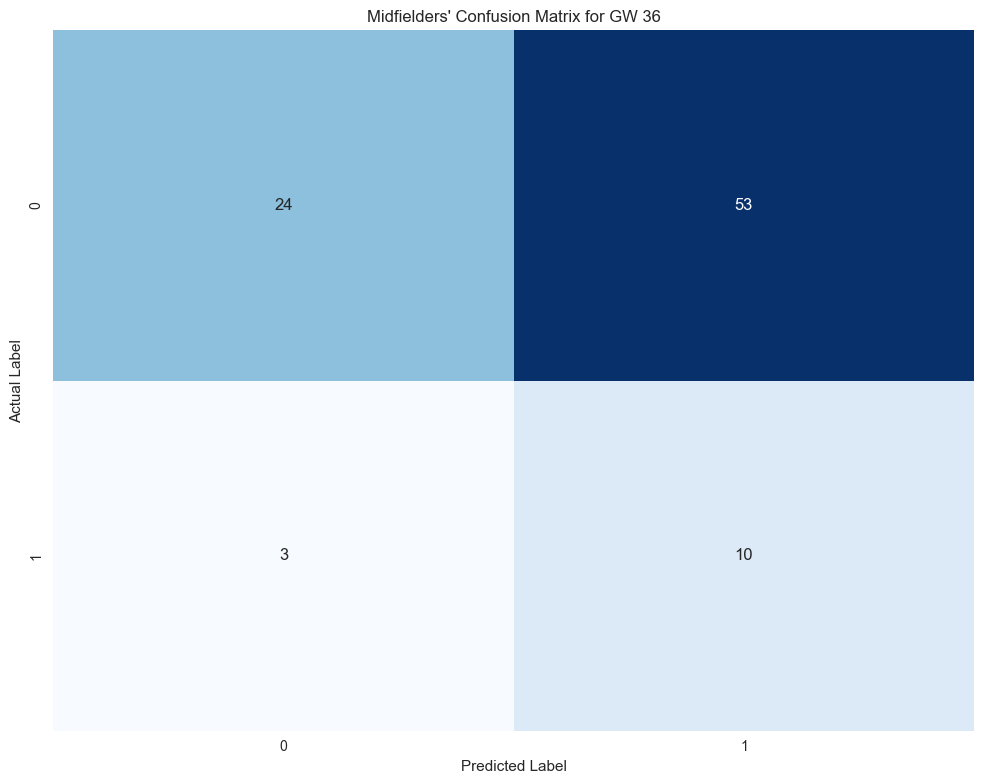

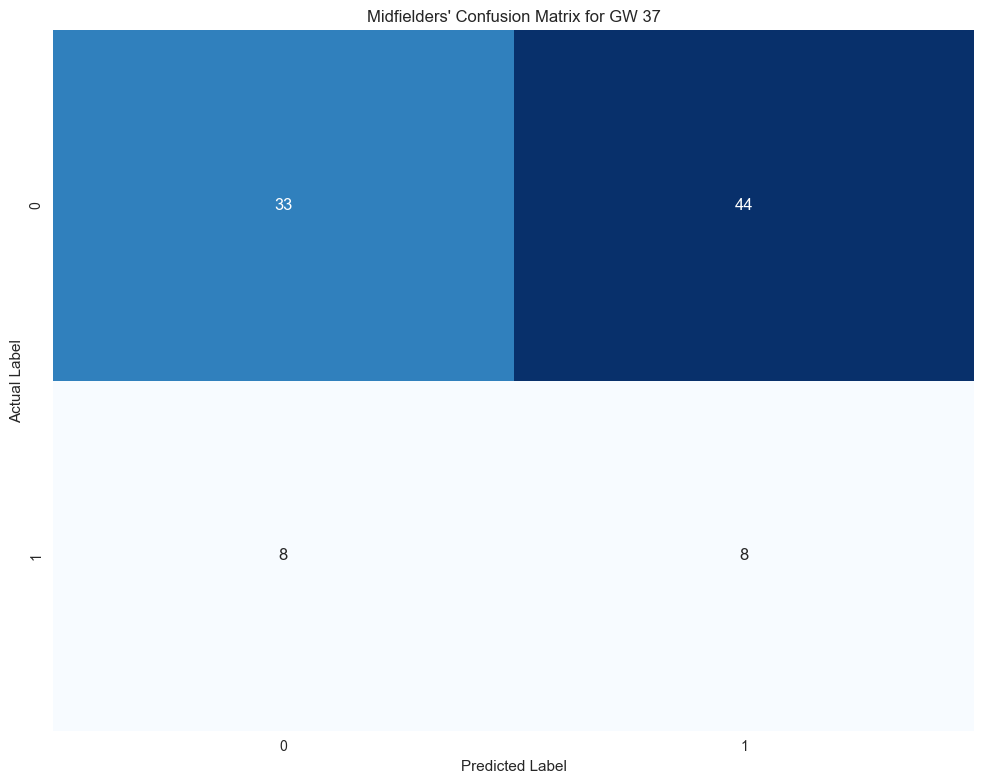

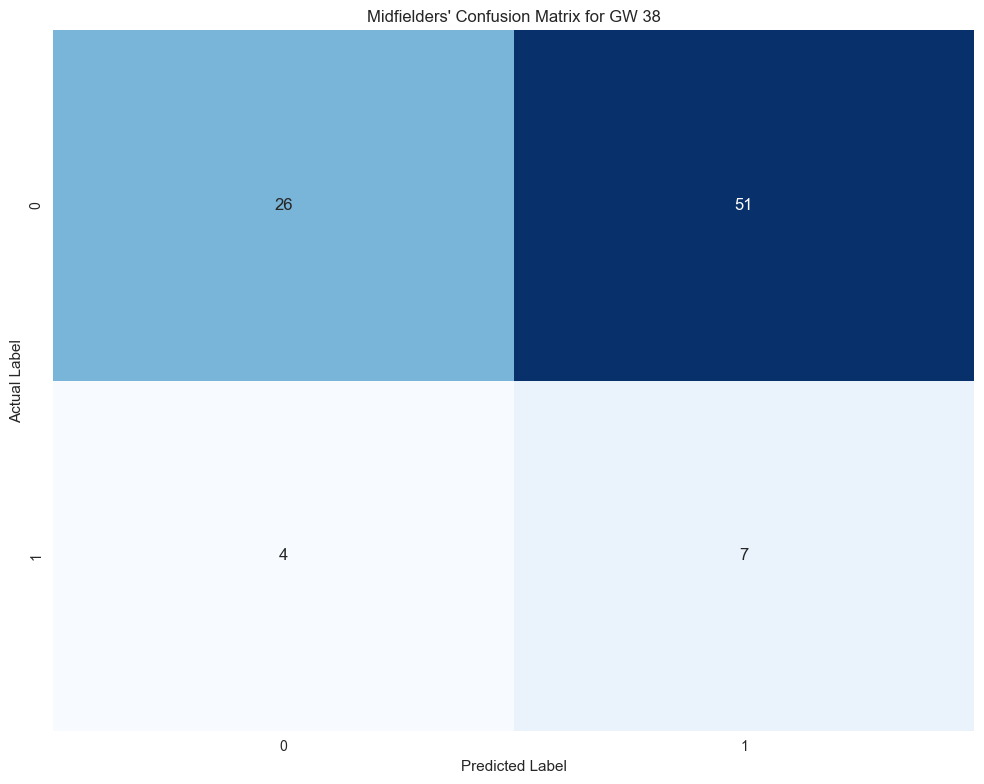

Transformation Pipeline and Model Successfully Loaded


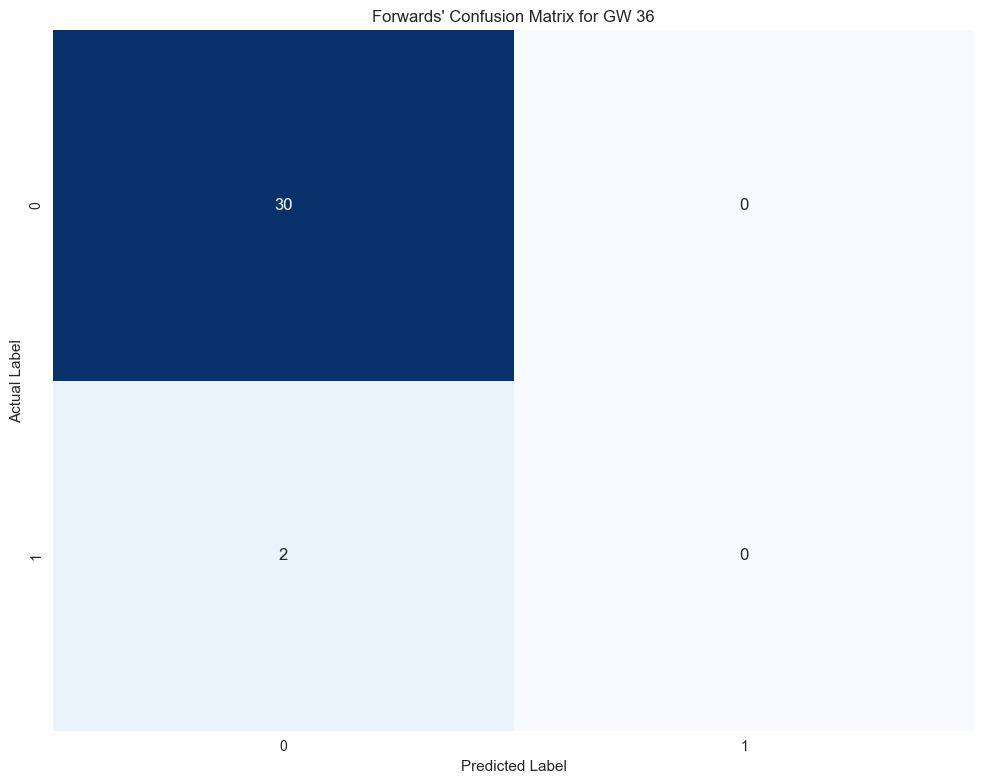

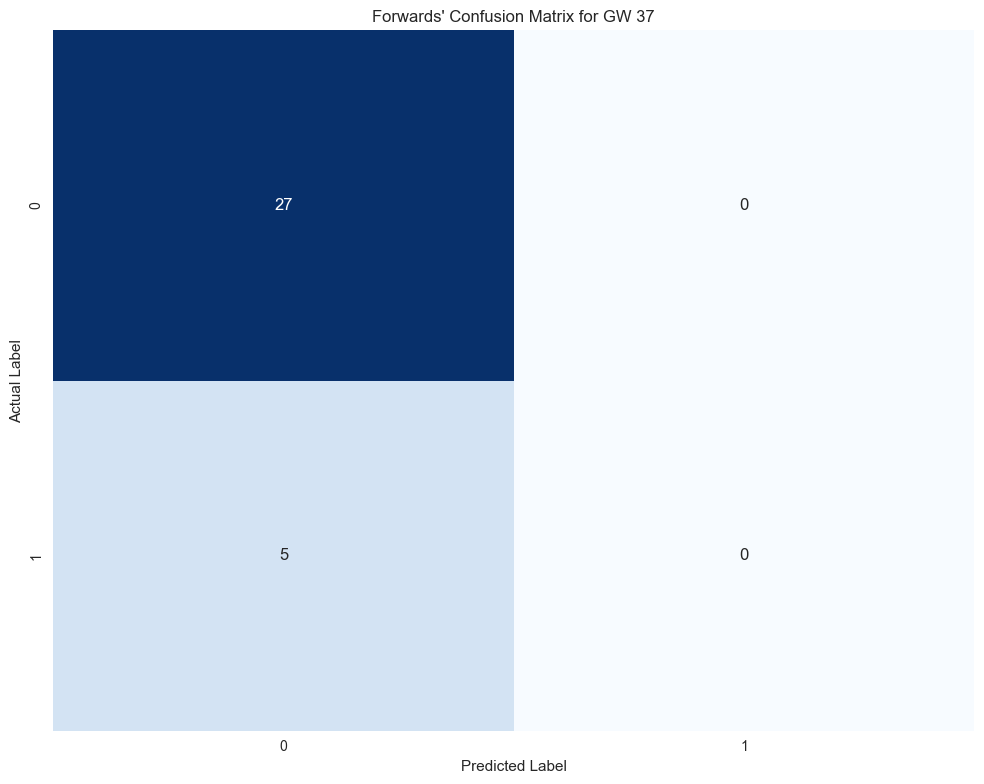

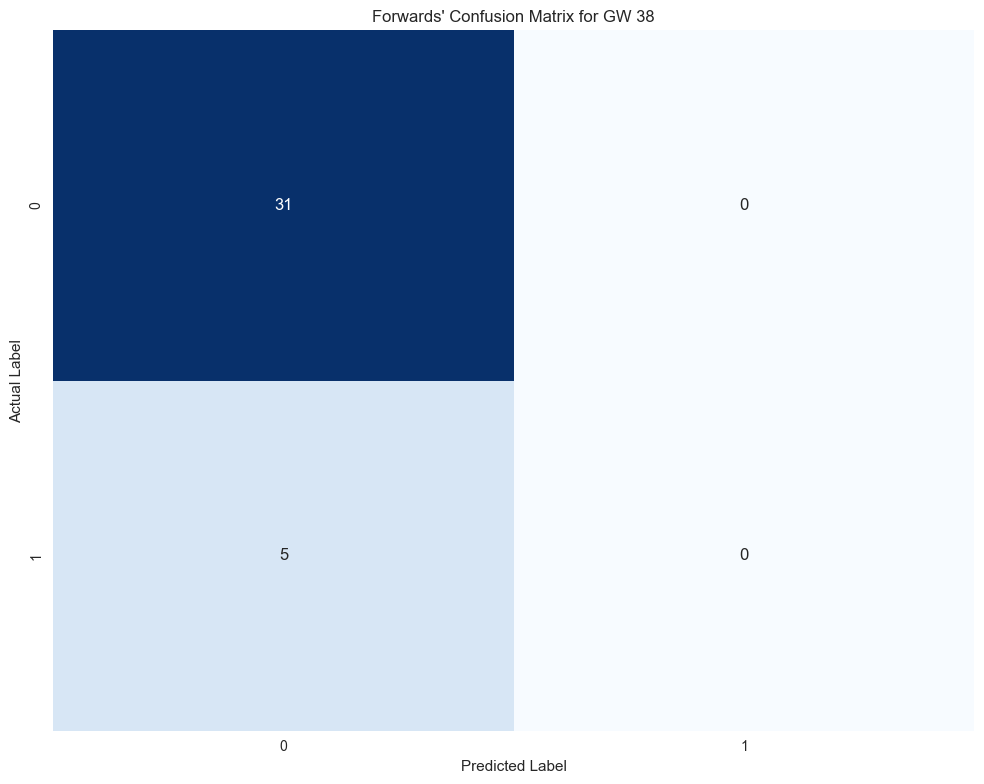

In [58]:
%run ./regression_predictor.ipynb
%run ./classifier_predictor.ipynb

# Fetch predictions


In [59]:
data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
data_37 = pd.read_csv('./data_37_with_preds.csv', index_col=0)
data_38 = pd.read_csv('./data_38_with_preds.csv', index_col=0)

data_36 = data_36.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
data_37 = data_37.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
data_38 = data_36.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})

In [60]:
def calc_xP_pred(row):
    # Minutes played bonus
    if row['minutes_3'] >= 60:
        minutes_bonus = 2
    elif row['minutes_3'] > 0:
        minutes_bonus = 1
    else:
        minutes_bonus = 0  # if player didn't play at all
    if row['position'] == 'GK':
        # print('GK')
        ## GK
        ## ---> >60  = 2
        ## ---> cs*4
        ## ---> ((sv)/3)*1
        ## ---> (gc/2)*-1
        ## ---> yc*-1
        return (
            minutes_bonus +
            4 * row['cs_preds'] +
            1 * round(row['saves_preds']/3, 3) -
            1 * round(row['xgc_preds']/2, 3) -
            1 * row['y_preds']
        )

    elif row['position'] == 'DEF':
        print('DEF')
        ## DEF
        ## ---> >60  = 2
        ## ---> xg*6
        ## ---> xa*3
        ## ---> cs*4
        ## ---> gc
        ## ---> yc*-1


        return (
            minutes_bonus +
            6 * row['xG_preds'] +
            3 * row['xA_preds'] +
            4 * row['cs_preds'] -
            1 * round(row['xgc_preds']/2, 3) -
            1 * row['y_preds']
        )
    elif row['position'] == 'MID':
        ## MID
        ## ---> >60  = +2
        ## ---> xg*5
        ## ---> xa*3
        ## ---> cs*1
        ## ---> yc*-1

        return (
            minutes_bonus +
            5 * row['xG_preds'] +
            3 * row['xA_preds'] +
            1 * row['cs_preds'] -
            1 * row['y_preds']
        )
    elif row['position'] == 'FWD':
        ## FWD
        ## ---> >60  = 2
        ## ---> xg*4
        ## ---> xa*3
        ## ---> yc*-1
        return (
            minutes_bonus +
            4 * row['xG_preds'] +
            3 * row['xA_preds'] -
            1 * row['y_preds']
        )
    else:
        return 0  # fallback for unknown positions


data_36['xP_preds'] = data_36.apply(calc_xP_pred, axis=1)
data_37['xP_preds'] = data_37.apply(calc_xP_pred, axis=1)
data_38['xP_preds'] = data_38.apply(calc_xP_pred, axis=1)

DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF
DEF


In [61]:
# id_name_df = pd.read_csv('../../fpl_understat_id_name.csv')

def add_player_name(row):
    # Check if fpl_id exists in id_name_df
    row['team'] = row['h_team'] if row['was_home'] else row['a_team']
    return row

data_36  = data_36.apply(add_player_name, axis=1, result_type='expand')
data_37  = data_37.apply(add_player_name, axis=1, result_type='expand')
data_38  = data_38.apply(add_player_name, axis=1, result_type='expand')

data_36.to_csv('./players_preds_36.csv', index=True)
data_37.to_csv('./players_preds_37.csv', index=True)
data_38.to_csv('./players_preds_38.csv', index=True)


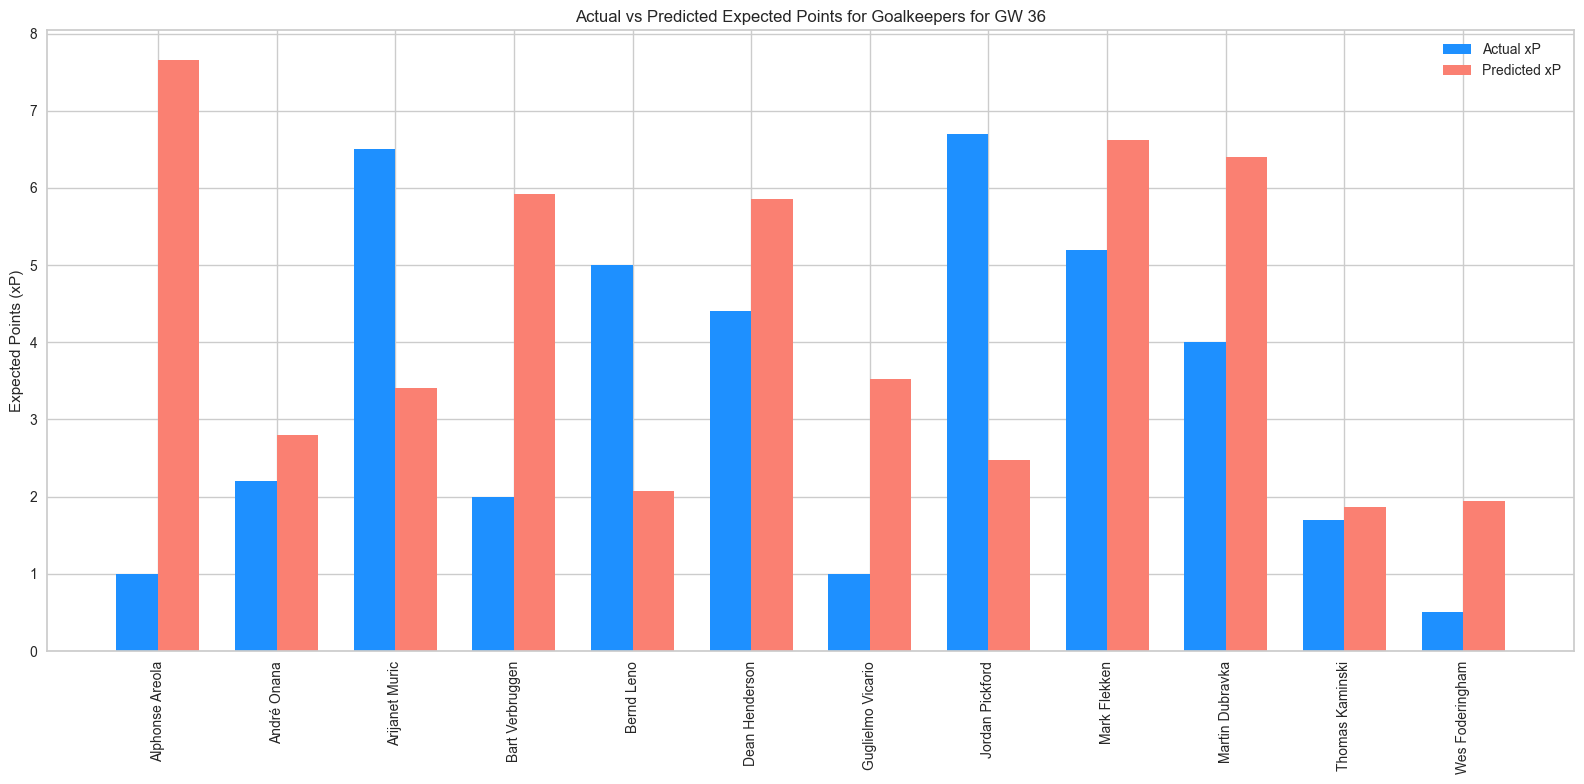

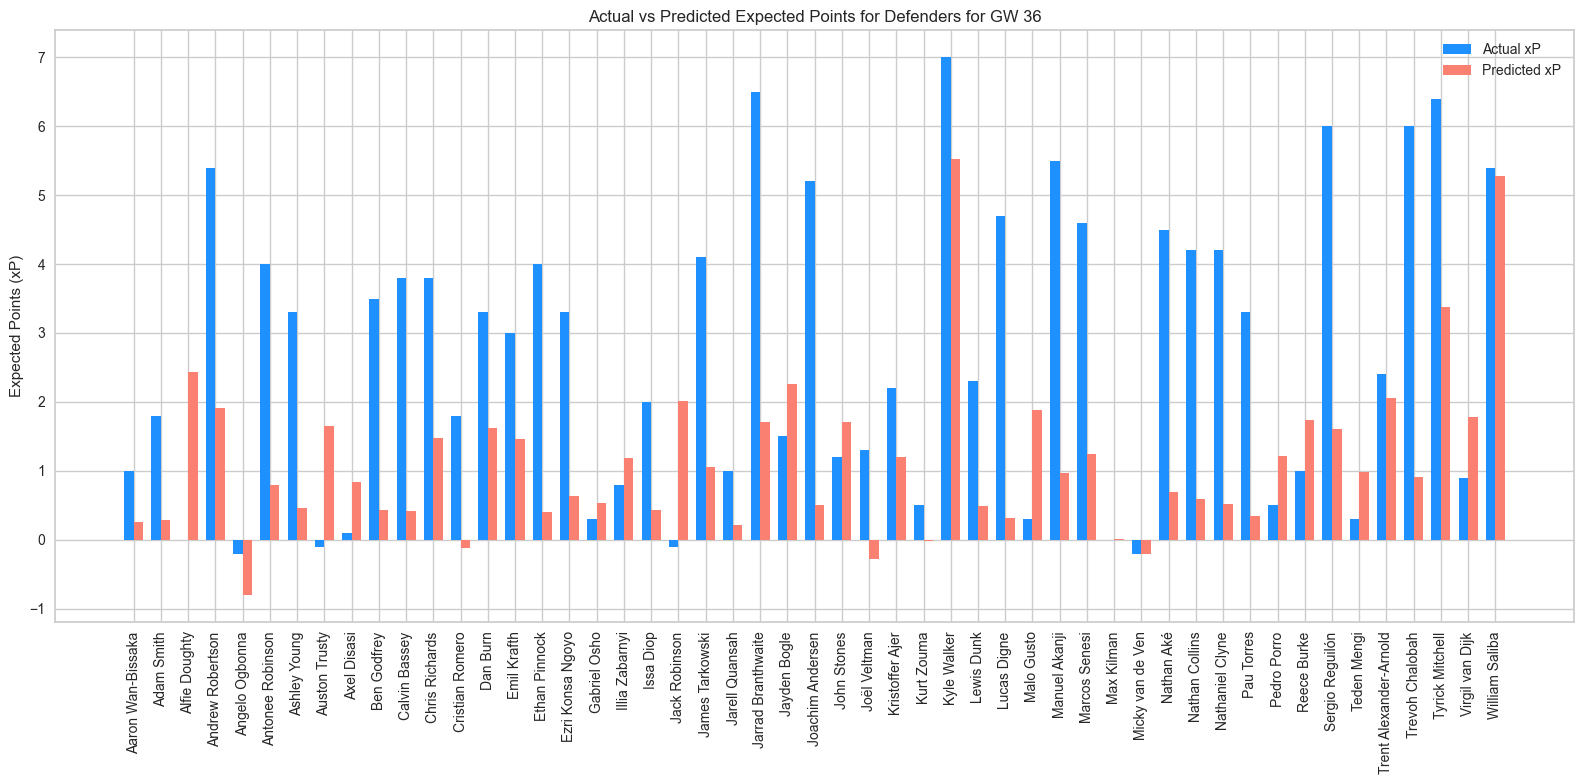

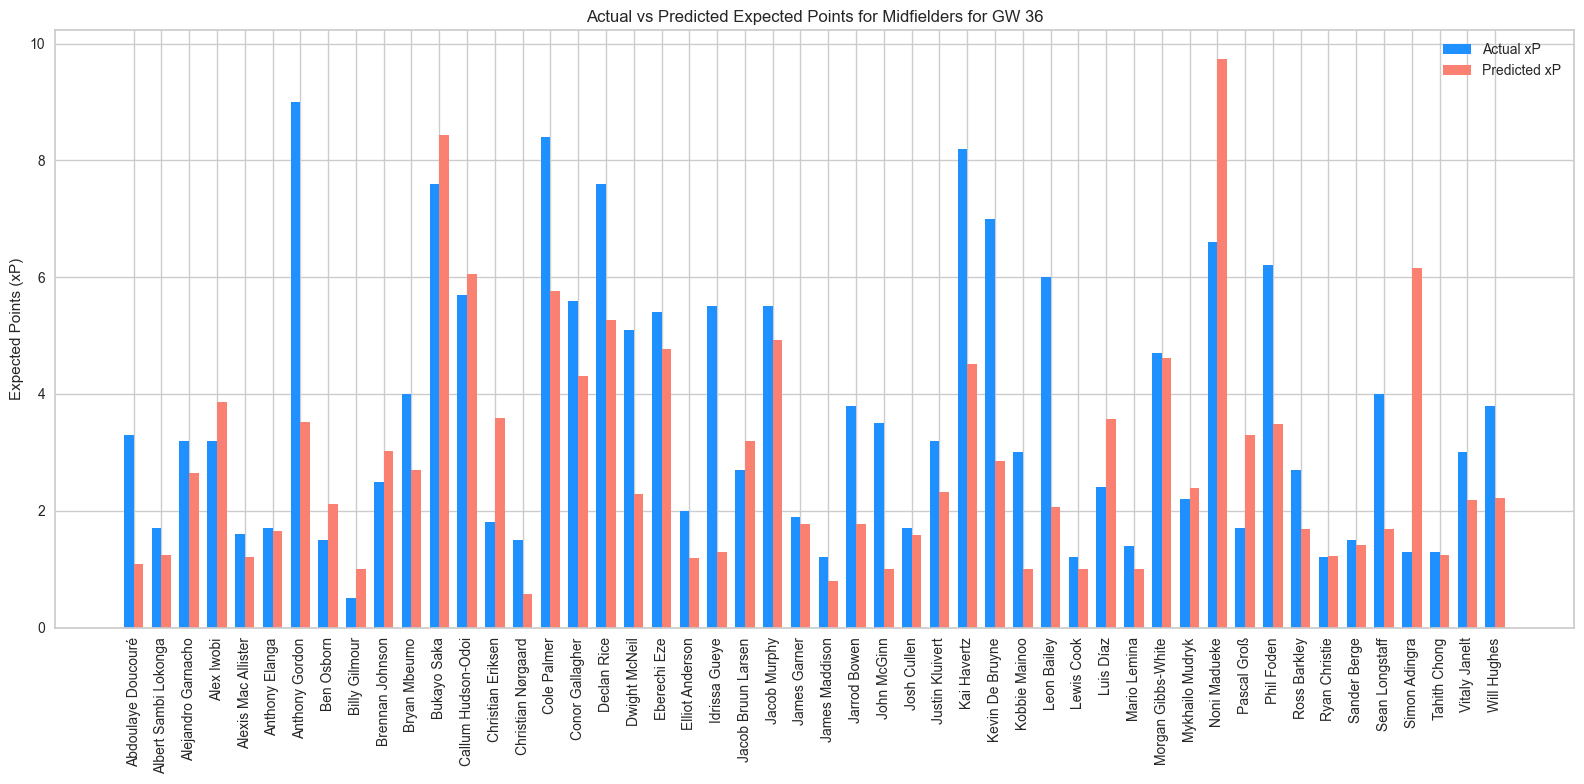

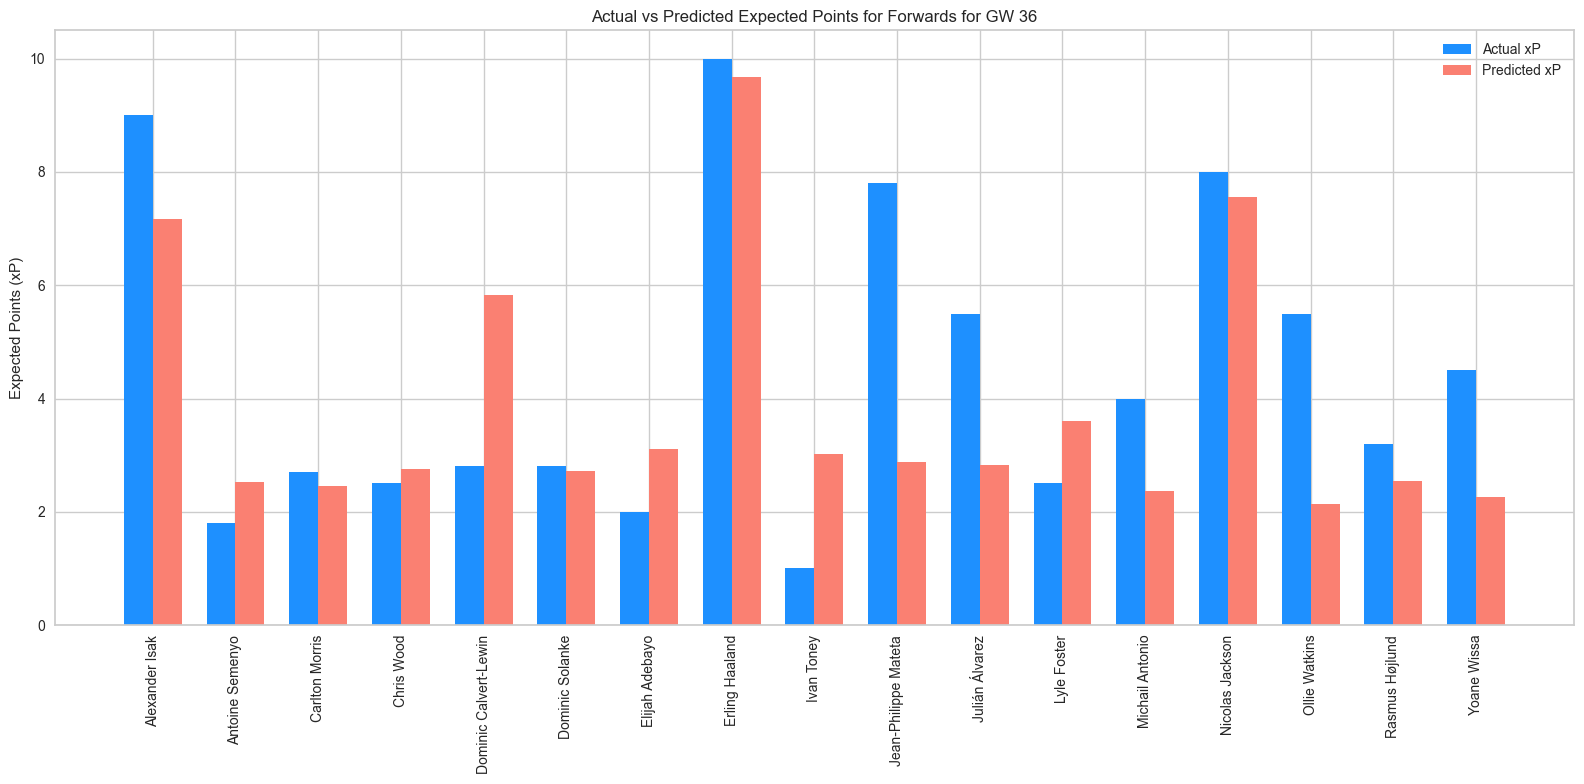

In [62]:
gk_36 = data_36[data_36['position'] == 'GK']
def_36 = data_36[data_36['position'] == 'DEF']
mid_36 = data_36[data_36['position'] == 'MID']
fwd_36 = data_36[data_36['position'] == 'FWD']

player_names_gk = gk_36['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_gk_names = player_names_gk[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_gk_names)) # The label locations
# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Goalkeepers for GW 36')
plt.xticks(x, clean_gk_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_def = def_36['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_def_names = player_names_def[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_def_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Defenders for GW 36')
plt.xticks(x, clean_def_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_mid = mid_36['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_mid_names = player_names_mid[:, 0]
# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_mid_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Midfielders for GW 36')
plt.xticks(x, clean_mid_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_fwd = fwd_36['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_fwd_names = player_names_fwd[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_fwd_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Forwards for GW 36')
plt.xticks(x, clean_fwd_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

## GW 37


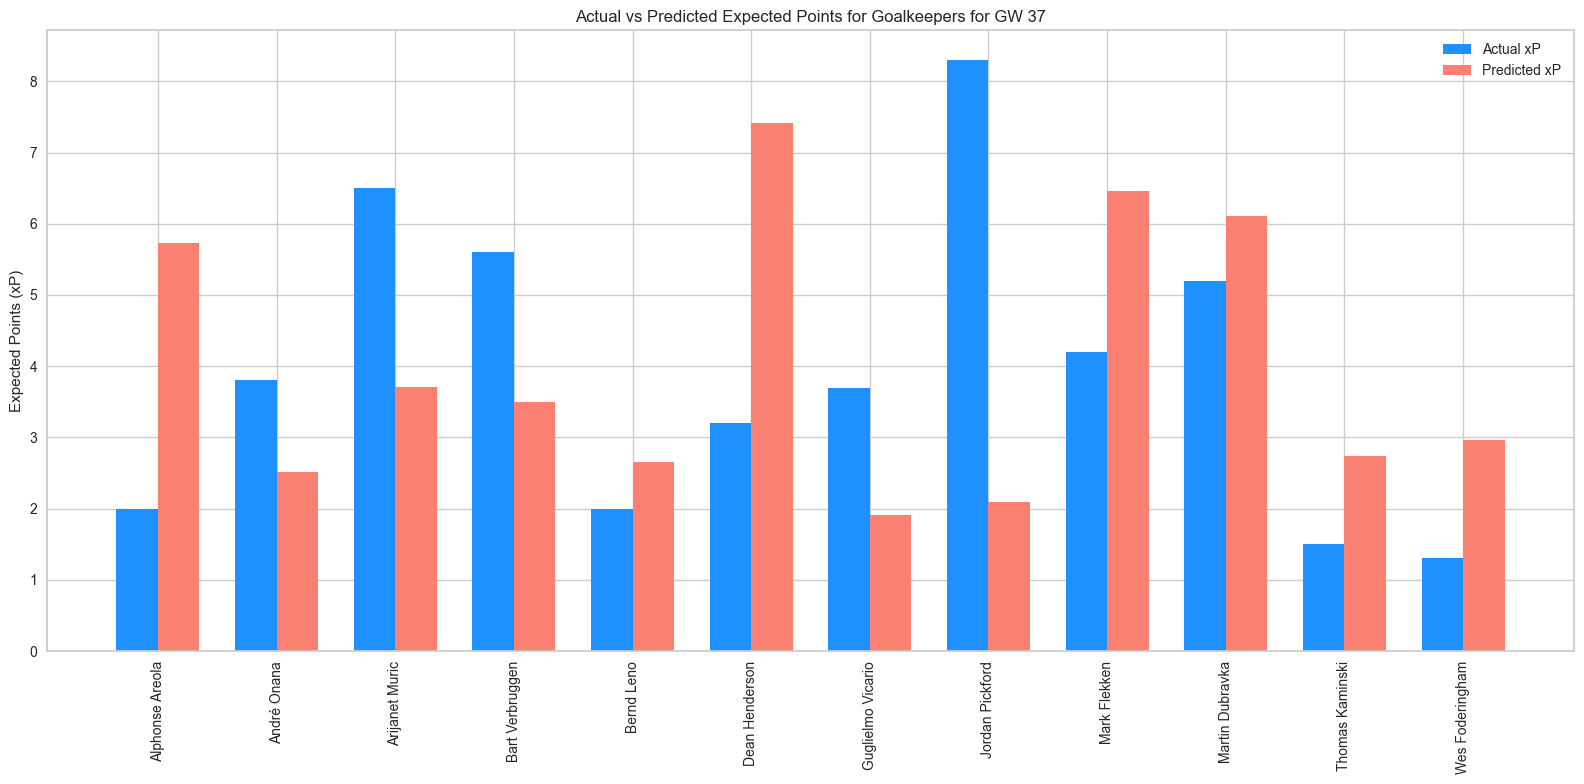

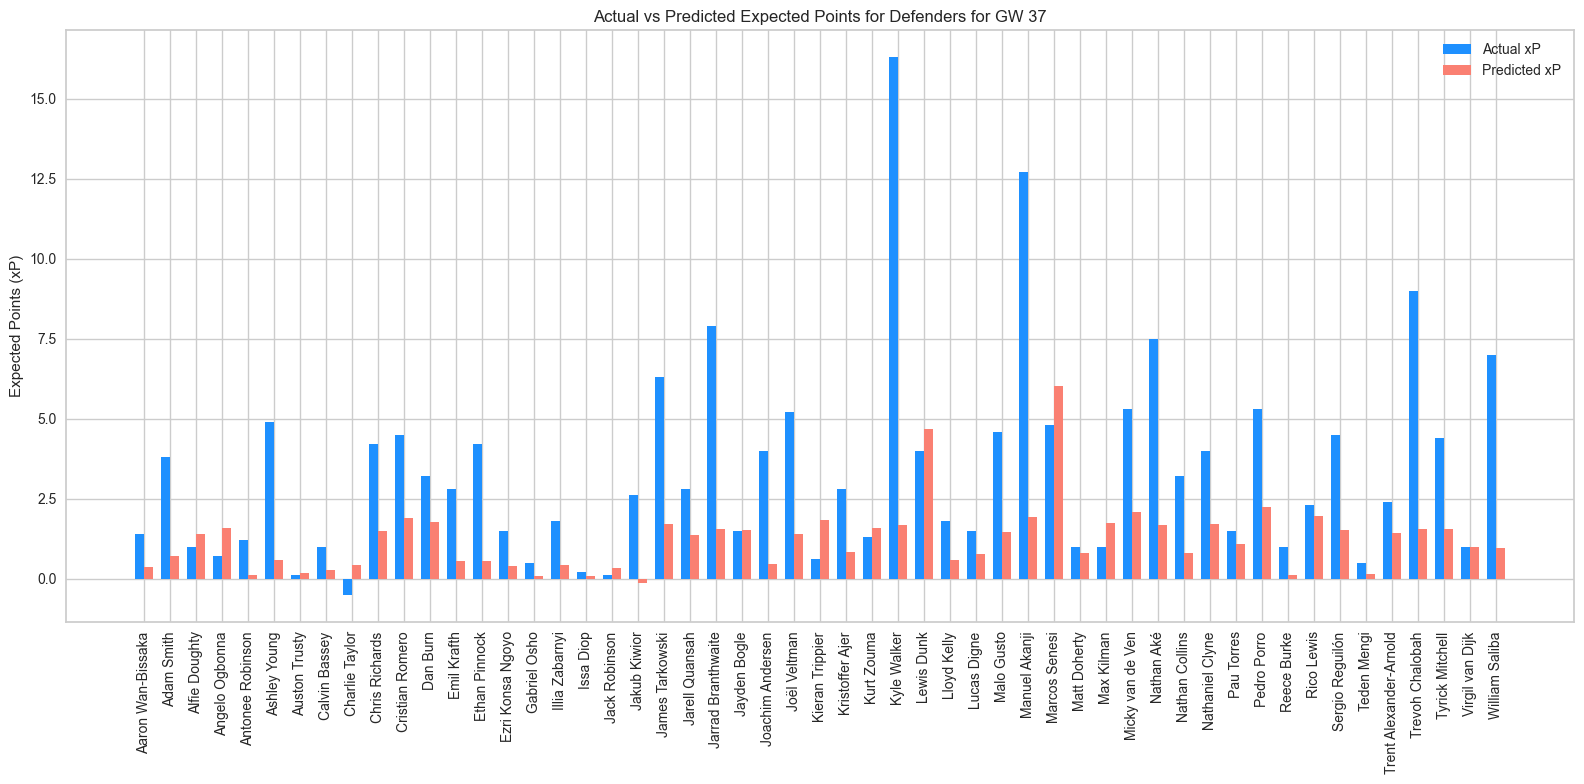

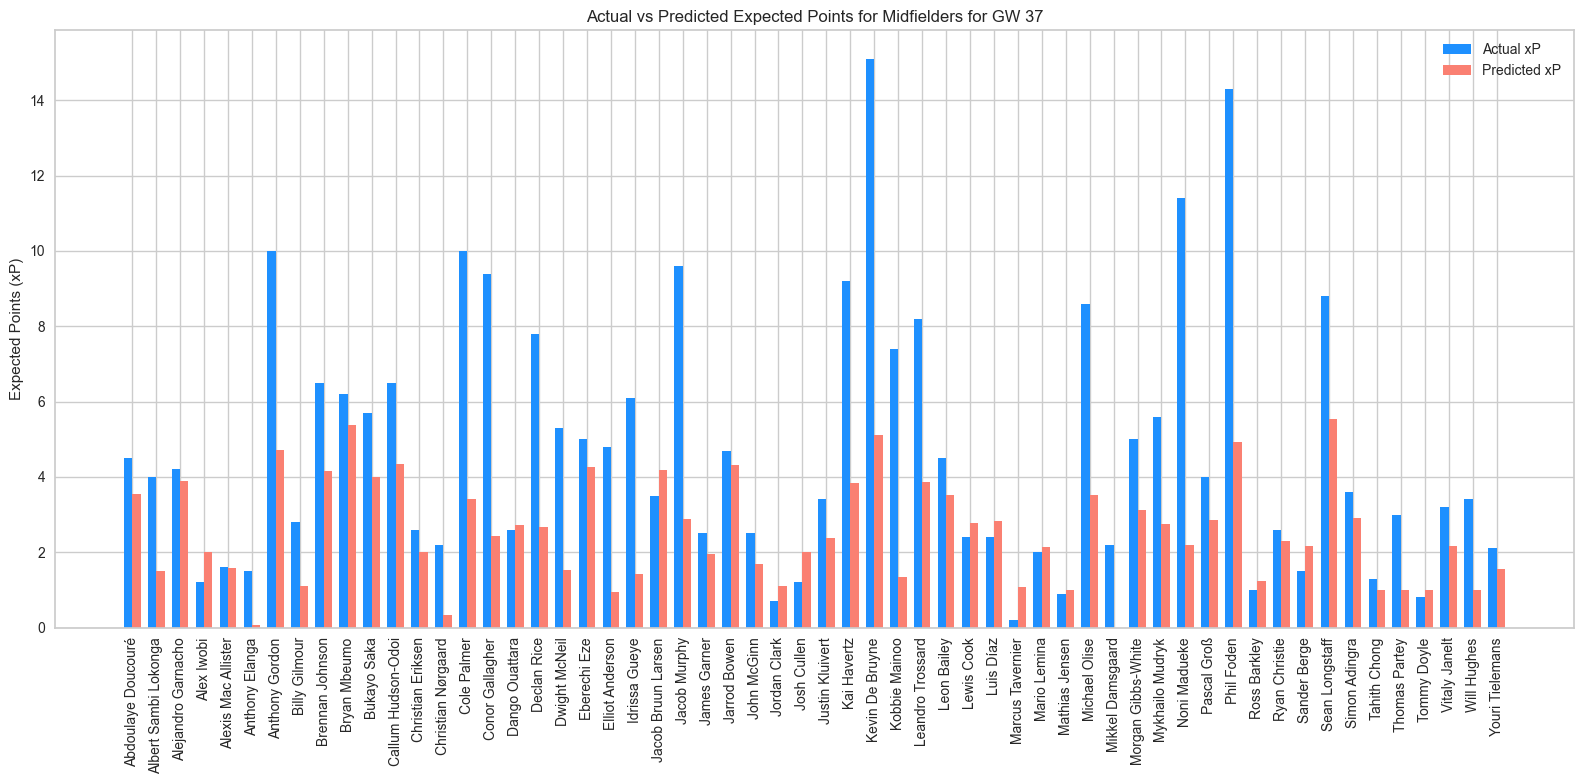

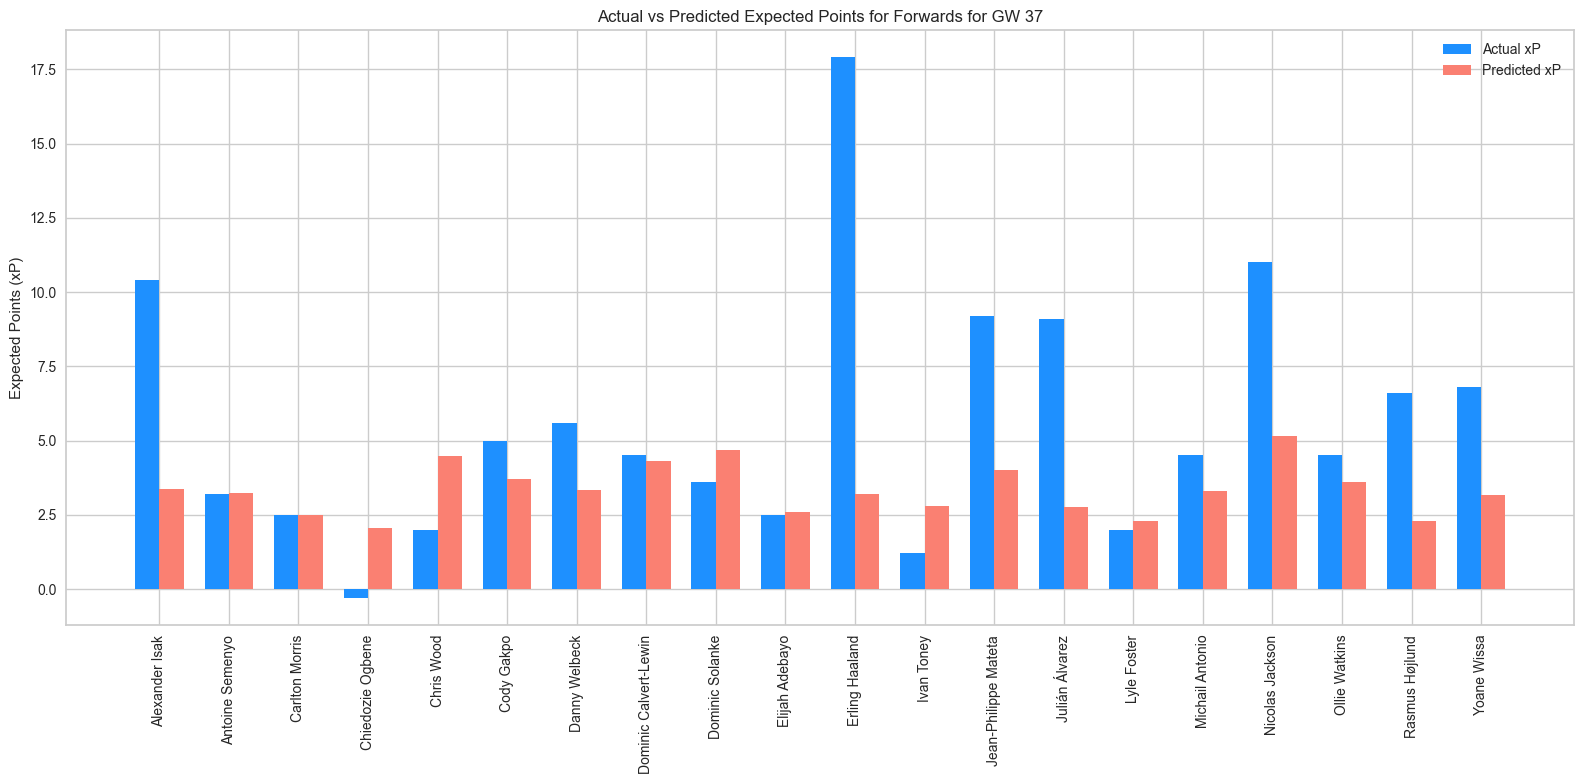

In [64]:
gk_37 = data_37[data_37['position'] == 'GK']
def_37 = data_37[data_37['position'] == 'DEF']
mid_37 = data_37[data_37['position'] == 'MID']
fwd_37 = data_37[data_37['position'] == 'FWD']

player_names_gk = gk_37['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_gk_names = player_names_gk[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_gk_names)) # The label locations
# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Goalkeepers for GW 37')
plt.xticks(x, clean_gk_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_def = def_37['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_def_names = player_names_def[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_def_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Defenders for GW 37')
plt.xticks(x, clean_def_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_mid = mid_37['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_mid_names = player_names_mid[:, 0]
# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_mid_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Midfielders for GW 37')
plt.xticks(x, clean_mid_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_fwd = fwd_37['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_fwd_names = player_names_fwd[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_fwd_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Forwards for GW 37')
plt.xticks(x, clean_fwd_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

## GW 38


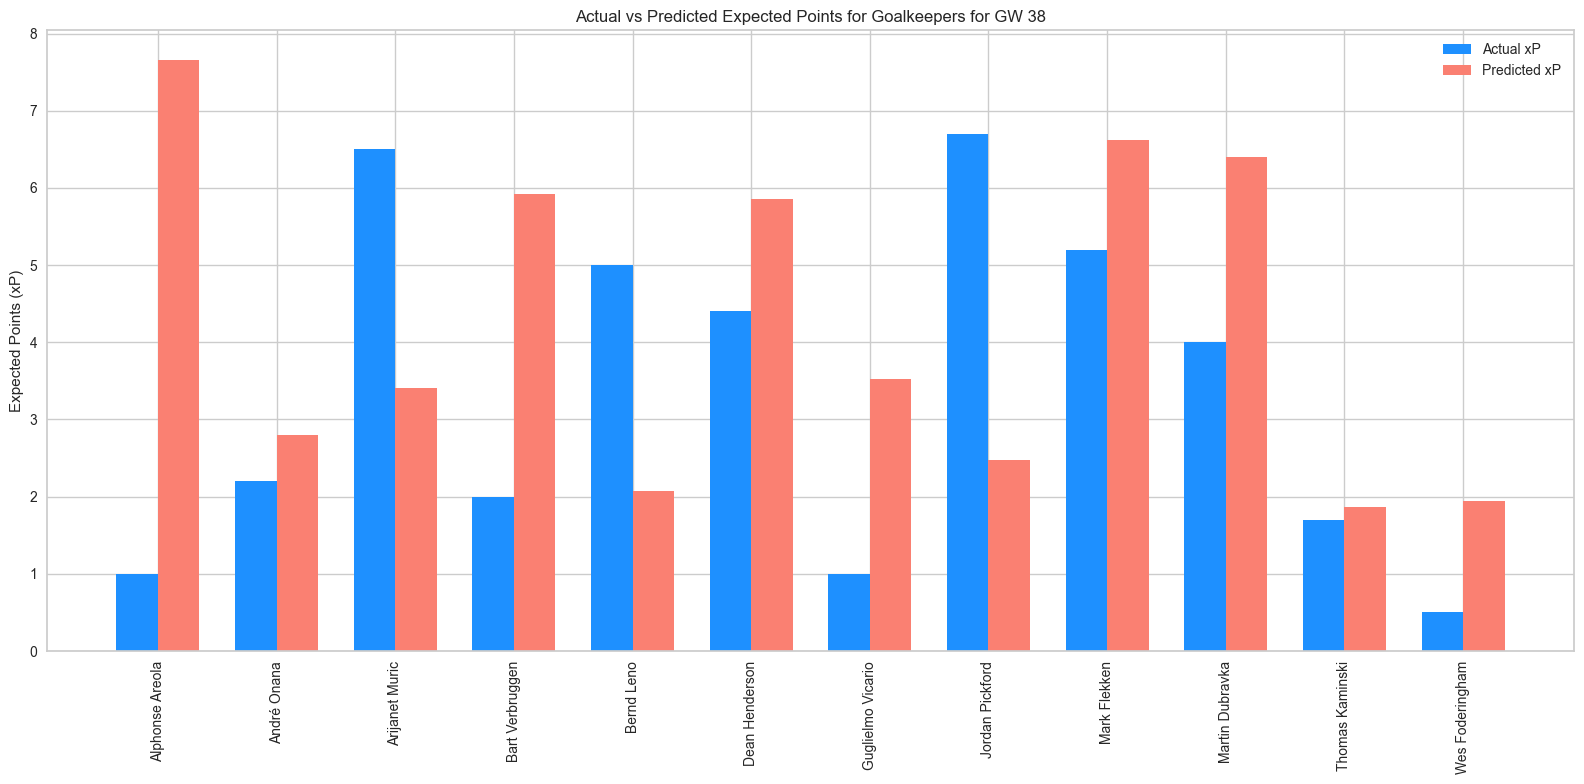

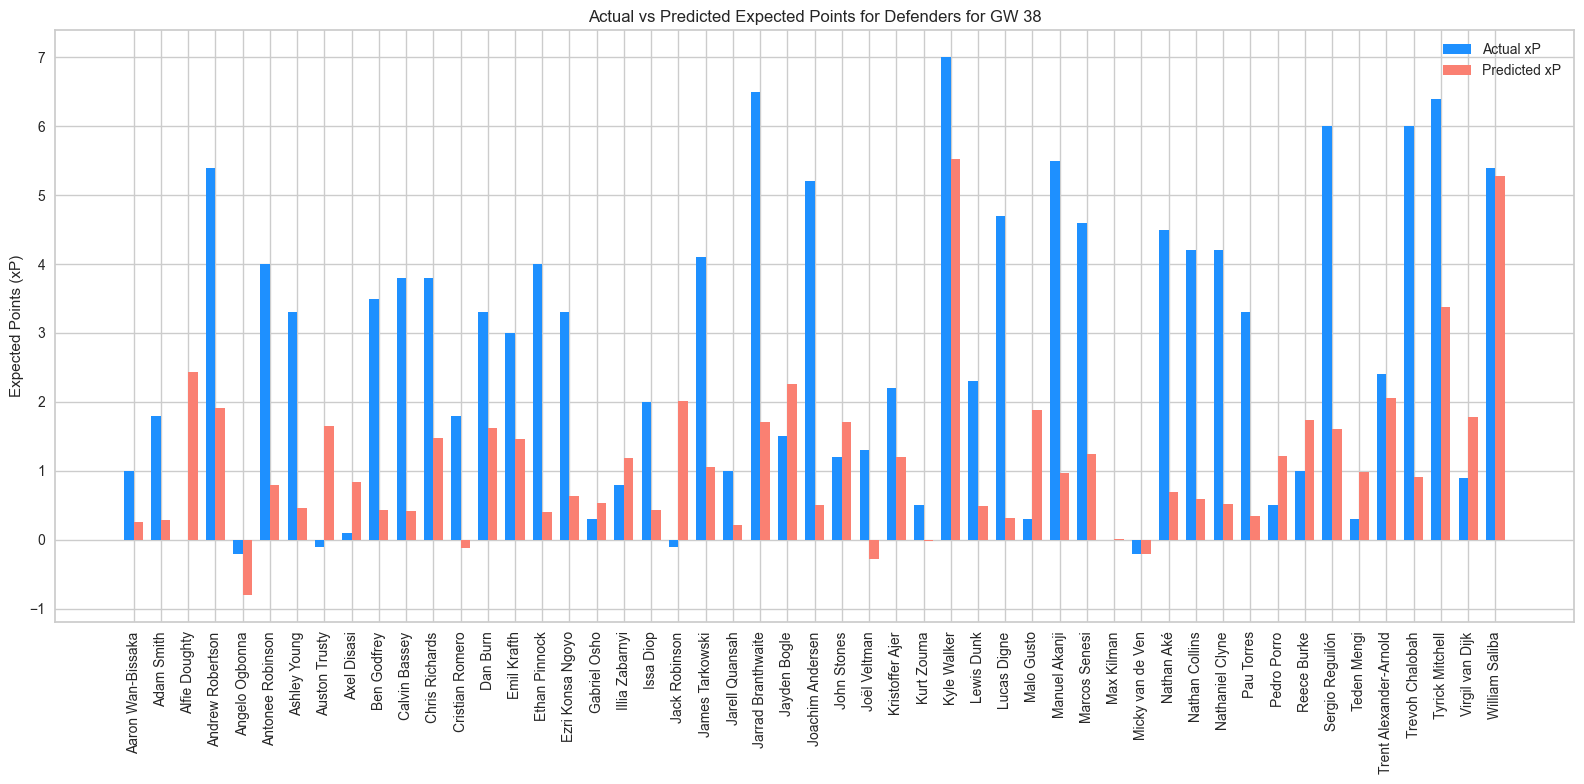

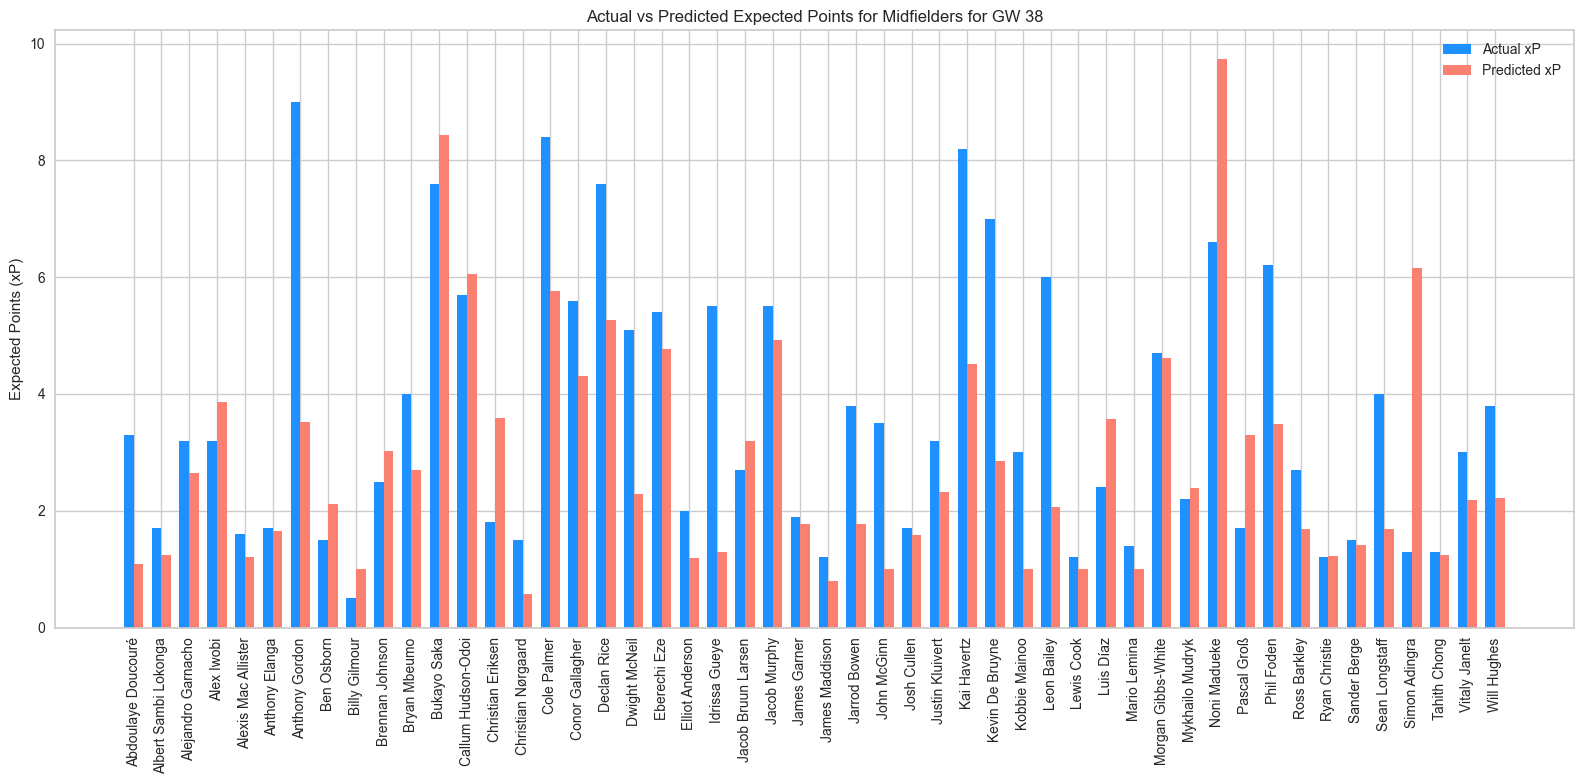

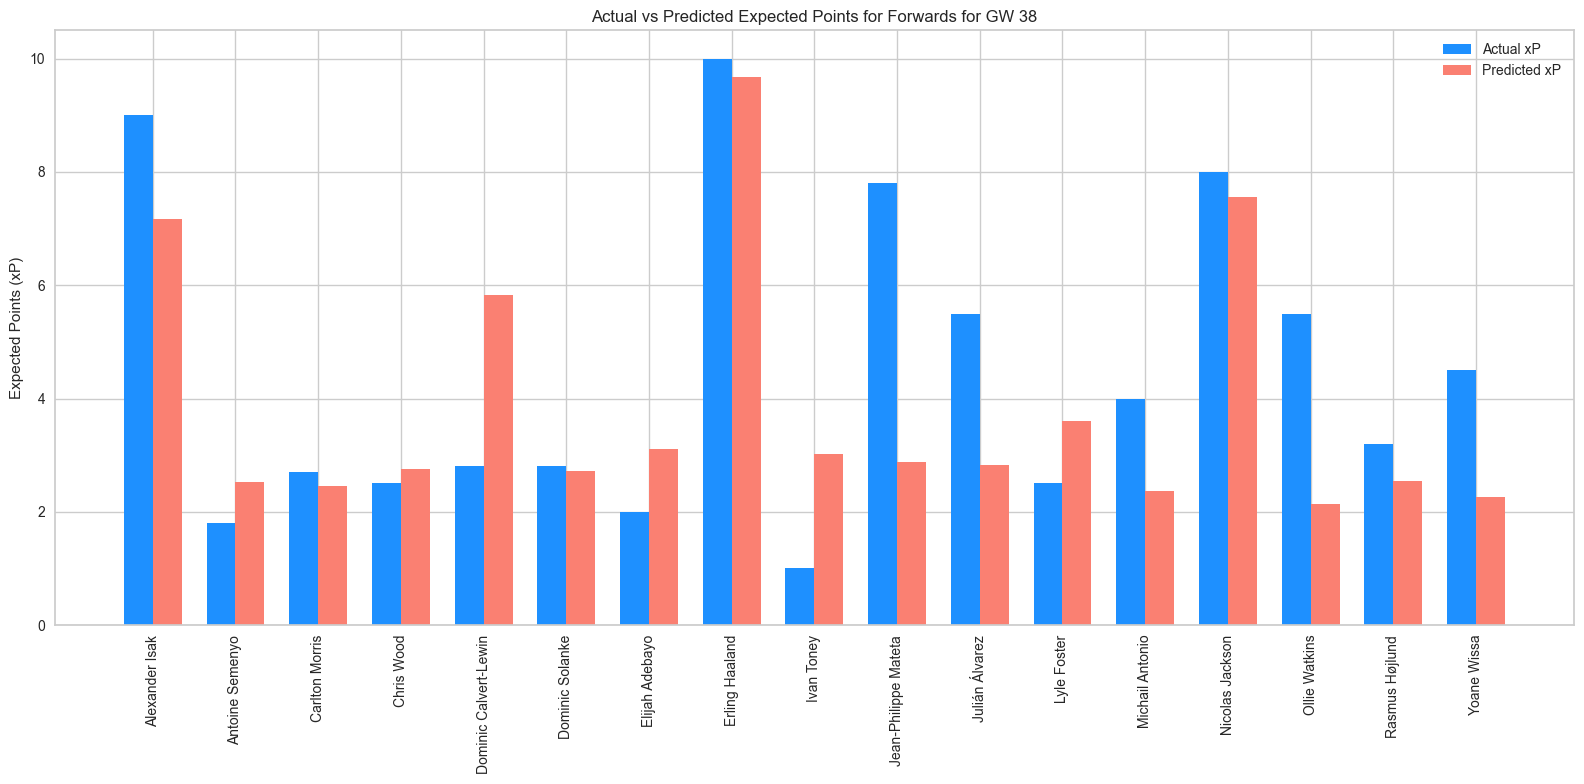

In [66]:
gk_38 = data_38[data_38['position'] == 'GK']
def_38 = data_38[data_38['position'] == 'DEF']
mid_38 = data_38[data_38['position'] == 'MID']
fwd_38 = data_38[data_38['position'] == 'FWD']

player_names_gk = gk_38['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_gk_names = player_names_gk[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_gk_names)) # The label locations
# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Goalkeepers for GW 38')
plt.xticks(x, clean_gk_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_def = def_38['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_def_names = player_names_def[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_def_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Defenders for GW 38')
plt.xticks(x, clean_def_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_mid = mid_38['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_mid_names = player_names_mid[:, 0]
# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_mid_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Midfielders for GW 38')
plt.xticks(x, clean_mid_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


player_names_fwd = fwd_38['fpl_name'].values

# 2. Slice the array to get ONLY the first column (index 0)
# This converts the array into a clean 1-dimensional list of 14 names
clean_fwd_names = player_names_fwd[:, 0]

# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(clean_fwd_names)) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Forwards for GW 38')
plt.xticks(x, clean_fwd_names, rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()